# Variable-Rate Reduced-Order Model for Reservoir Pressure Dynamics

**Extends the single-schedule ROM to arbitrary variable-rate histories via Duhamel superposition.**

---

## Theoretical Foundation

For a single-phase, slightly-compressible reservoir the diffusivity equation is **linear in pressure**:

$$\frac{\partial p}{\partial t} = \frac{k}{\phi\mu c_t}\nabla^2 p$$

This linearity guarantees the **superposition principle (Duhamel's theorem)**: the bottomhole
pressure response to any arbitrary rate history $q(t)$ can be expressed as a convolution of the
unit-step drawdown response $h(t)$ [psi/(STB/d)] and the rate change history:

$$\Delta p_{wf}(t) = \int_0^t h(t-\tau)\,\frac{dq}{d\tau}\,d\tau$$

For a **piecewise-constant** schedule with $N$ steps at times $t_0=0 < t_1 < \cdots < t_{N-1}$:

$$\boxed{\Delta p_{wf}(t) = \sum_{j=0}^{N-1}\frac{\Delta q_j}{q_\mathrm{ref}}\,h(t-t_j^+), \qquad h(t<0)\equiv 0}$$

where $\Delta q_j = q_j - q_{j-1}$ (negative for a rate decrease or shut-in).

The **ROM state-space model** is *exactly* a continuous-time LTI system:

$$\dot{\hat{x}} = \hat{A}\hat{x} + \hat{B}\,u(t), \qquad y = \hat{C}\hat{x} + \hat{D}\,u(t)$$

so Duhamel superposition holds **exactly** — it provides a rigorous linearity check.

### Rate Transient Analysis (RTA)

For variable-rate data the **Material Balance Time** (Blasingame *et al.*, 1991) collapses the
response onto the equivalent constant-rate drawdown curve:

$$t_e = \frac{N_p(t)}{q(t)}, \qquad N_p(t) = \int_0^t q(\tau)\,d\tau$$

The **Rate-Normalized Pressure** and its log-log derivative are:

$$\mathrm{RNP}(t_e) = \frac{\Delta p_{wf}}{q}, \qquad \mathrm{RNP}'(t_e) = \frac{d\,\mathrm{RNP}}{d\ln t_e}$$

In the MTR, both RNP and RNP$'$ become constant on the log-log plot — the hallmark of
infinite-acting radial flow, regardless of the rate schedule.

### Horner Build-up

After production at rate $q$ for equivalent time $t_p$ then shut-in for $\Delta t$:

$$p_{ws}(\Delta t) = p_i - m\log_{10}\!\left(\frac{t_p+\Delta t}{\Delta t}\right), \qquad m = \frac{162.6\,q\mu B_o}{kh}$$


## 0. Imports, Paths and Global Configuration

In [66]:
import json, pickle, shutil, warnings, time
from pathlib import Path

import h5py
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator
from scipy.linalg import expm
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "dejavuserif",
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 12,
    "axes.titleweight": "bold", "legend.fontsize": 9,
    "axes.grid": False, "figure.dpi": 130, "savefig.dpi": 300,
    "lines.linewidth": 1.8,
})

C1, C2, C3, C4  = "#1a5e9e", "#0d6e56", "#9b2a1a", "#b07318"
C_MRST, C_ROM   = "#2C5F8A", "#C0392B"
C_DUH, C_RNP    = "#6A0572", "#025E73"   # colours for new modules

# ── Directory layout ──────────────────────────────────────────────────────
TRAINING_DIR = Path("../data/01_training")
VAL_DIR      = Path("../data/02_validation")
ROM_DIR      = Path("../rom_vrate")
FIG_DIR      = Path("../figures_vrate");  FIG_DIR.mkdir(parents=True, exist_ok=True)
for _d in ["basis","operators","interpolants","results"]:
    (ROM_DIR / _d).mkdir(parents=True, exist_ok=True)

# ── Reservoir constants (field units) ────────────────────────────────────
P_INIT  = 4500.0        # psia
NX, NY  = 50, 50
N_CELLS = NX * NY
N_STEPS = 350
T_START, T_END = 0.001, 5000.0
PHI    = 0.18
CT     = 1.2e-5         # psi⁻¹
MU_CP  = 1.2            # cp
BO     = 1.15           # RB/STB
H_FT   = 150.0          # ft
RW_FT  = 0.35           # ft
C_WBS  = 0.003          # bbl/psi
DX_FT  = 30 * 3.28084   # ft
RE_FT  = (NX * 30 / 2) * 3.28084
WC_IDX = (NY//2 - 1)*NX + (NX//2 - 1)   # 1224  (Python 0-indexed)

K_GRID = [10, 20, 50, 100, 200, 300]
S_GRID = [0, 1, 2, 4, 6, 8]
SCHEDS = list(range(1, 8))

print(f"Training data : {TRAINING_DIR.resolve()}")
print(f"ROM output    : {ROM_DIR.resolve()}")
print(f"Well cell idx : {WC_IDX}  (0-indexed)")
print(f"RE_FT         : {RE_FT:.1f} ft")


Training data : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
ROM output    : F:\Niloy Deb\Part Two\reservoir_rom\rom_vrate
Well cell idx : 1224  (0-indexed)
RE_FT         : 2460.6 ft


## 1. Rate Schedule Inventory and Training Data Validation

All 7 MRST schedules are catalogued from the saved `params.json` files.
Variable-rate schedules (schedules with $>1$ control period) are the main focus of this notebook.


In [24]:
# ── I/O helpers ───────────────────────────────────────────────────────────
def load_mat(filepath, key):
    try:
        return sio.loadmat(str(filepath), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(filepath), "r") as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr

def load_well_data(case_dir):
    wd  = case_dir / "well_data.mat"
    bhp = load_mat(wd, "bhp_psia").ravel()
    t   = load_mat(wd, "time_hr").ravel()
    q   = load_mat(wd, "rate_STBd").ravel()
    dp  = load_mat(wd, "delta_p_psi").ravel()
    with open(case_dir / "params.json") as f:
        pm = json.load(f)
    return bhp, t, q, dp, pm

def get_schedule_shape(pm):
    """Return (rates_STBd array, t_change_hr array) from params dict."""
    rates = np.atleast_1d(pm["rates_STBd"])
    t_ch  = np.atleast_1d(pm.get("t_change_hr", []))
    return rates, t_ch

# ── Physics screening (identical to primary notebook) ─────────────────────
def n_log_steps(ta, tb, t_start=T_START, t_end=T_END, n=N_STEPS):
    ta, tb = max(ta, t_start), min(tb, t_end)
    if tb <= ta: return 0
    return int(n * np.log10(tb/ta) / np.log10(t_end/t_start))

def physics_screen(k, s):
    kh    = k * H_FT
    t_wbs = 170000.0 * C_WBS * MU_CP * np.exp(0.14*s) / kh
    t_pss = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * k) * 0.1
    n_wbs = n_log_steps(T_START, t_wbs)
    n_mtr = n_log_steps(t_wbs, t_pss)
    n_bdf = n_log_steps(t_pss, T_END)
    if t_wbs >= T_END:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "t_WBS >= T_end"
    if t_wbs >= t_pss:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "no MTR"
    if n_mtr < 15:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, f"n_MTR={n_mtr}<15"
    return True, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "VALID"

VALID_PAIRS = [(k,s) for k in K_GRID for s in S_GRID
               if physics_screen(k,s)[0]]
print(f"Valid (k,S) training pairs : {len(VALID_PAIRS)} / {len(K_GRID)*len(S_GRID)}")


Valid (k,S) training pairs : 36 / 36


In [25]:
# ── Catalogue all 7 schedules from params.json ────────────────────────────
sched_rows = []
for sid in SCHEDS:
    # Read from any valid (k,S) pair — schedule metadata is identical across k,S
    for k, s in VALID_PAIRS:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        if (cd / "params.json").exists():
            try:
                _, t, q, _, pm = load_well_data(cd)
                rates, t_ch   = get_schedule_shape(pm)
                n_ctrl         = len(rates)
                label          = pm.get("schedule_label", f"sched{sid}")
                rate_str       = " → ".join(f"{int(r)}" for r in rates)
                t_ch_str       = ", ".join(f"{v:.0f}" for v in t_ch) if len(t_ch) > 0 else "—"
                sched_rows.append(dict(
                    sched_id=sid, label=label, n_controls=n_ctrl,
                    rates_STBd=rate_str, t_changes_hr=t_ch_str,
                    is_variable=(n_ctrl > 1)))
            except Exception:
                pass
            break

df_sched = pd.DataFrame(sched_rows).drop_duplicates("sched_id").set_index("sched_id")
print("Rate Schedule Inventory")
print("=" * 70)
print(df_sched.to_string())
VARIABLE_SCHEDS = df_sched[df_sched["is_variable"]].index.tolist()
SINGLE_SCHEDS   = df_sched[~df_sched["is_variable"]].index.tolist()
print(f"\nSingle-rate schedules  : {SINGLE_SCHEDS}")
print(f"Variable-rate schedules: {VARIABLE_SCHEDS}")


Rate Schedule Inventory
                  label  n_controls        rates_STBd t_changes_hr  is_variable
sched_id                                                                       
1                 q800c           1               800            —        False
2                 q400c           1               400            —        False
3                q1200c           1              1200            —        False
4            q1000to500           2        1000 → 500         1000         True
5             q400to900           2         400 → 900         1000         True
6           q800buildup           2           800 → 0         2500         True
7         q600_1000_300           3  600 → 1000 → 300   1667, 3333         True

Single-rate schedules  : [1, 2, 3]
Variable-rate schedules: [4, 5, 6, 7]


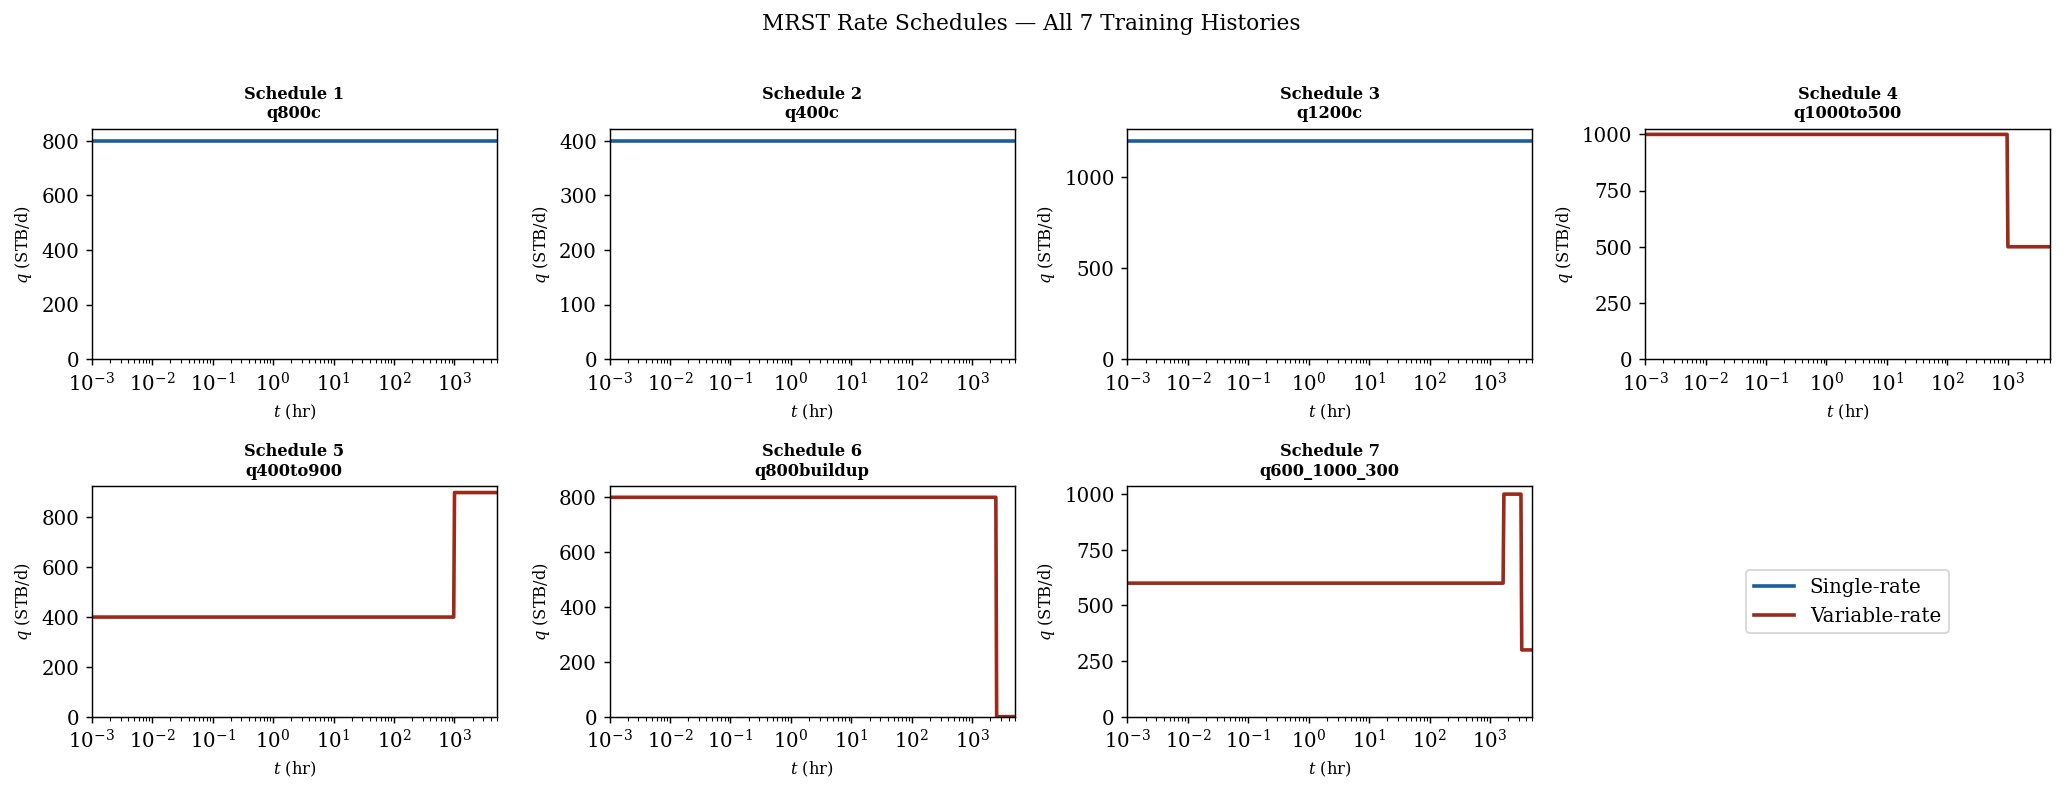

In [26]:
# ── Plot rate histories for all 7 schedules ───────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
axes_flat = axes.ravel()
T_HIST = np.logspace(np.log10(T_START), np.log10(T_END), 500)

for si, sid in enumerate(SCHEDS):
    ax = axes_flat[si]
    for k, s in VALID_PAIRS[:1]:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        try:
            _, t, q, _, pm = load_well_data(cd)
            rates, t_ch = get_schedule_shape(pm)
            # Build step function
            q_hist = np.full(len(T_HIST), float(rates[0]))
            for j, tc in enumerate(t_ch):
                q_hist[T_HIST >= tc] = float(rates[j+1]) if (j+1)<len(rates) else 0.0
            col = C3 if len(rates) > 1 else C1
            ax.semilogx(T_HIST, q_hist, color=col, lw=2)
            ax.set_xlabel("$t$ (hr)", fontsize=9)
            ax.set_ylabel("$q$ (STB/d)", fontsize=9)
            lbl = pm.get("schedule_label", f"sched{sid}")
            ax.set_title(f"Schedule {sid}\n{lbl}", fontsize=9, fontweight="bold")
            ax.set_xlim([T_START, T_END])
            ax.set_ylim(bottom=0)
        except Exception:
            ax.text(0.5, 0.5, "Missing", ha="center", transform=ax.transAxes)

axes_flat[-1].axis("off")
leg = [Line2D([0],[0],color=C1,lw=2,label="Single-rate"),
       Line2D([0],[0],color=C3,lw=2,label="Variable-rate")]
axes_flat[-1].legend(handles=leg, loc="center", fontsize=11)
plt.suptitle("MRST Rate Schedules — All 7 Training Histories", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig01_rate_schedules.pdf", bbox_inches="tight")
plt.show()


In [27]:
# ── File integrity check across all valid (k,S,sched) triples ─────────────
issues = []
for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        for fname in ["snapshots_psia.mat", "well_data.mat", "params.json"]:
            if not (cd/fname).exists():
                issues.append((name, f"{fname} missing"))
                continue
        try:
            X = load_mat(cd/"snapshots_psia.mat","X_psia")
            if X.shape[0] != N_CELLS:
                issues.append((name, f"wrong rows {X.shape[0]}"))
            if not np.isfinite(X).all():
                issues.append((name, "NaN/Inf"))
        except Exception as e:
            issues.append((name, str(e)))

total = len(VALID_PAIRS) * len(SCHEDS)
print(f"Checked : {total}  (k,S,sched) combinations")
if issues:
    print(f"Issues  : {len(issues)}")
    for nm, msg in issues[:15]: print(f"  {nm}: {msg}")
else:
    print("All files present, correct shape, finite values.")


Checked : 252  (k,S,sched) combinations
All files present, correct shape, finite values.


## 2. POD Basis Construction

All valid (k, S) pairs **and all 7 schedules** contribute to the snapshot matrix.
Temporal weighting ($w_j = \sqrt{\Delta t_j}$) de-emphasises the densely-sampled
early-time region so that each flow regime contributes equitably to the basis.

$$Z = \bigl[\sqrt{\Delta t}\,\odot\,(X - p_i)\bigr]_{\text{all cases}}$$

SVD: $Z = U \Sigma V^T$.  Basis $V_n = U_{:,1:n}$.


In [28]:
snap_cols, cases_pod = [], []

for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        try:
            X  = load_mat(cd/"snapshots_psia.mat","X_psia")
            dX = X - P_INIT
            _, t, _, _, _ = load_well_data(cd)
            dt = np.diff(t, prepend=0.0); dt[0] = t[0]
            w  = np.sqrt(dt); w /= (w.mean() + 1e-12)
            snap_cols.append(dX * w)
            cases_pod.append(name)
        except FileNotFoundError:
            print(f"  Missing: {name}")

Z = np.hstack(snap_cols)
print(f"Snapshot matrix Z : {Z.shape}  ({Z.nbytes/1e6:.0f} MB)")
print(f"Cases (k,S,sched) : {len(cases_pod)}")
print("Computing SVD ...")
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f"Done.  σ₁={sigma[0]:.2f}  σ_last={sigma[-1]:.2e}")


Snapshot matrix Z : (2500, 88200)  (1764 MB)
Cases (k,S,sched) : 252
Computing SVD ...
Done.  σ₁=2245963.70  σ_last=2.04e-11


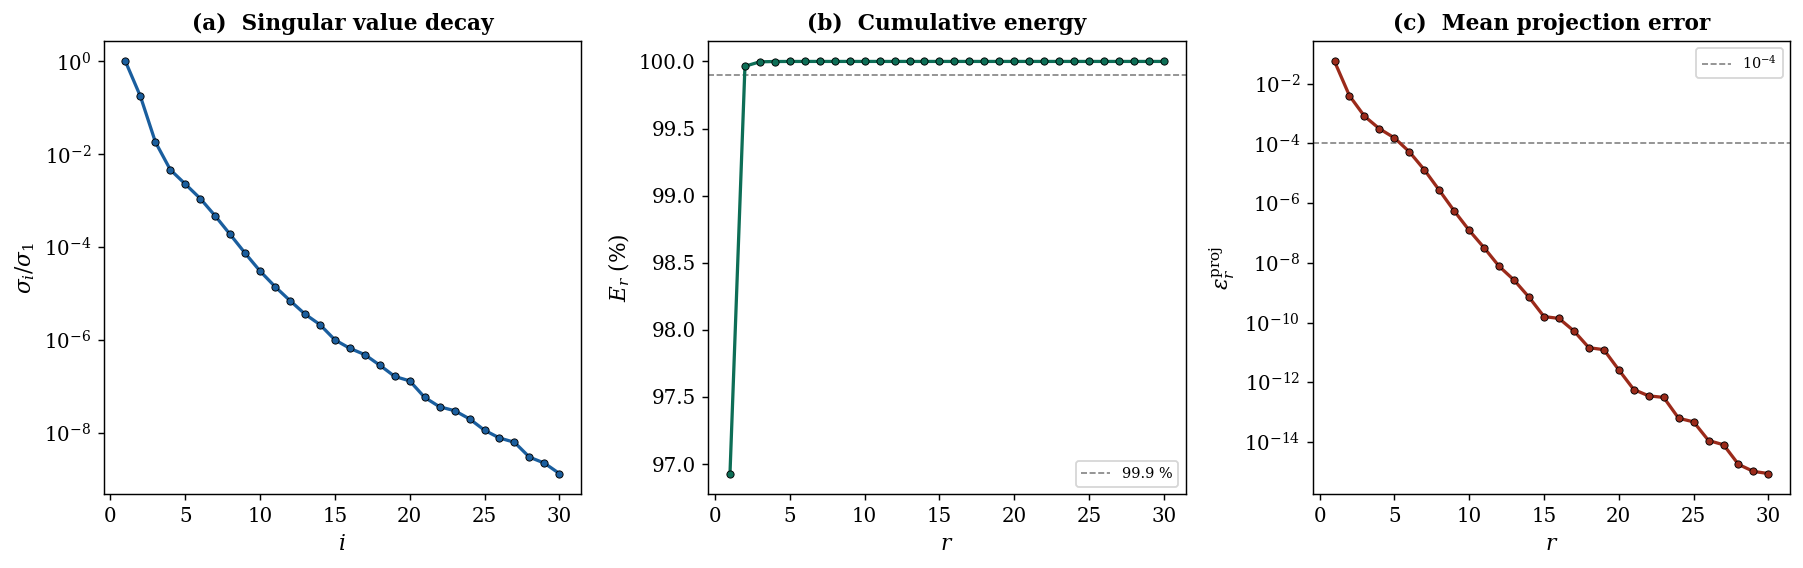

Modes for 99.9% energy      : 2
Modes for proj error < 1e-4 : 6


In [29]:
# ── Mode count selection ──────────────────────────────────────────────────
cum_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
N_SHOW     = min(30, len(sigma))

# Projection error vs mode count
n_try_range = np.arange(1, N_SHOW+1)
proj_errors = []
for n_try in n_try_range:
    Vt = U[:, :n_try]
    err = 0.0
    for k, s in VALID_PAIRS:
        try:
            X  = load_mat(TRAINING_DIR/f"k{k:03d}_s{s:02d}_sched1"/"snapshots_psia.mat","X_psia") - P_INIT
            Xr = Vt @ (Vt.T @ X)
            err += np.linalg.norm(X-Xr,"fro")**2 / (np.linalg.norm(X,"fro")**2 + 1e-12)
        except FileNotFoundError:
            pass
    proj_errors.append(err / max(len(VALID_PAIRS),1))
proj_errors = np.array(proj_errors)

kw = dict(marker="o", ms=4, mec="k", mew=0.5, zorder=3)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].semilogy(range(1,N_SHOW+1), sigma[:N_SHOW]/sigma[0], color=C1, **kw)
axes[0].set_xlabel("$i$"); axes[0].set_ylabel(r"$\sigma_i/\sigma_1$")
axes[0].set_title("(a)  Singular value decay")

axes[1].plot(range(1,N_SHOW+1), cum_energy[:N_SHOW]*100, color=C2, **kw)
axes[1].axhline(99.9, color="k", ls="--", lw=0.9, alpha=0.5, label="99.9 %")
axes[1].set_xlabel("$r$"); axes[1].set_ylabel("$E_r$ (%)")
axes[1].set_title("(b)  Cumulative energy"); axes[1].legend(fontsize=8)

axes[2].semilogy(n_try_range, proj_errors, color=C3, **kw)
axes[2].axhline(1e-4, color="k", ls="--", lw=0.9, alpha=0.5, label=r"$10^{-4}$")
axes[2].set_xlabel("$r$"); axes[2].set_ylabel(r"$\varepsilon_r^\mathrm{proj}$")
axes[2].set_title("(c)  Mean projection error"); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig02_pod_convergence.pdf", bbox_inches="tight")
plt.show()

n99  = int(np.argmax(cum_energy >= 0.999)) + 1
n1e4 = int(np.argmax(proj_errors < 1e-4)) + 1 if np.any(proj_errors < 1e-4) else "not reached"
print(f"Modes for 99.9% energy      : {n99}")
print(f"Modes for proj error < 1e-4 : {n1e4}")


In [30]:
N_MODES = 15
Vn      = U[:, :N_MODES]

# Projection errors across ALL schedules
per_err = []
for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        try:
            X  = load_mat(TRAINING_DIR/f"k{k:03d}_s{s:02d}_sched{sid}"/"snapshots_psia.mat","X_psia") - P_INIT
            Xr = Vn @ (Vn.T @ X)
            per_err.append(np.linalg.norm(X-Xr,"fro")**2 / (np.linalg.norm(X,"fro")**2+1e-12))
        except FileNotFoundError:
            pass

print(f"N_MODES selected : {N_MODES}")
print(f"Basis shape Vn   : {Vn.shape}")
print(f"Orthogonality    : ||VnT·Vn − I||_inf = {np.abs(Vn.T@Vn - np.eye(N_MODES)).max():.2e}")
print(f"Proj error (mean): {np.mean(per_err):.2e}   max: {np.max(per_err):.2e}")

np.save(ROM_DIR/"basis"/"Vn.npy",    Vn)
np.save(ROM_DIR/"basis"/"sigma.npy", sigma)
print(f"Basis saved → {ROM_DIR/'basis'}/")


N_MODES selected : 15
Basis shape Vn   : (2500, 15)
Orthogonality    : ||VnT·Vn − I||_inf = 1.11e-15
Proj error (mean): 1.75e-10   max: 1.36e-09
Basis saved → ..\rom_vrate\basis/


## 3. Operator Inference

The variable-rate schedules provide **richer excitation** of the state space than single-rate
training, improving identifiability of $\hat{A}$ and $\hat{B}$.

Projected state dynamics:
$$\hat{x}(t) = V_n^T\,(p(t) - p_i), \qquad \dot{\hat{x}} \approx \hat{A}\hat{x} + \hat{B}\,q$$

Least-squares formulation (time-weighted):
$$\min_{\hat{A},\hat{B}} \sum_j w_j \left\|\dot{\hat{x}}_j - \hat{A}\hat{x}_j - \hat{B}\,q_j\right\|_2^2 + \lambda\|[\hat{A}\;\hat{B}]\|_F^2$$

The observation pair $(\hat{C}, \hat{D})$:
- $\hat{C}$ is set analytically to the well-cell row of $V_n$.
- $\hat{D}$ absorbs skin + WBS effects via scalar least-squares over the full
  variable-rate excitation history (all schedules simultaneously).


In [31]:
def infer_AB(Vn, X_list, U_list, T_list, t_wbs_list, lam_mult=1.0):
    """
    Infer (Â, B̂) from a collection of state trajectories and rate inputs.
    Time-weighted finite-difference approximation of dx̂/dt.
    """
    n_r = Vn.shape[1]
    Xhat_rows, U_rows, R_rows, W_rows = [], [], [], []
    for X, u, t, t_wbs in zip(X_list, U_list, T_list, t_wbs_list):
        dX   = X - P_INIT
        Xhat = (Vn.T @ dX).T          # [N_t × n_r]
        dt   = np.diff(t, prepend=0.0); dt[0] = t[0]
        R    = np.zeros_like(Xhat)
        R[0] = Xhat[0] / dt[0]
        for j in range(1, len(t)):
            R[j] = (Xhat[j] - Xhat[j-1]) / dt[j]
        i_s = 1
        w   = np.sqrt(dt[i_s:]); w /= (w.mean() + 1e-12)
        Xhat_rows.append(Xhat[i_s:])
        U_rows.append(u[i_s:].reshape(-1, 1))
        R_rows.append(R[i_s:])
        W_rows.append(w)

    Xhat_all = np.vstack(Xhat_rows);  U_all = np.vstack(U_rows)
    R_all    = np.vstack(R_rows);     W_all = np.concatenate(W_rows)
    D        = np.hstack([Xhat_all, U_all])
    cond_D   = np.linalg.cond(D)
    col_norms= np.linalg.norm(D, axis=0) + 1e-12
    D_w      = (D / col_norms) * W_all[:, None]
    R_w      = R_all * W_all[:, None]
    lam      = 1e-6 * lam_mult * np.trace(D_w.T @ D_w) / D_w.shape[1]
    nc       = D_w.shape[1]
    D_aug    = np.vstack([D_w, np.sqrt(lam)*np.eye(nc)])
    R_aug    = np.vstack([R_w, np.zeros((nc, n_r))])
    OT_sc, *_= np.linalg.lstsq(D_aug, R_aug, rcond=None)
    OT       = OT_sc / col_norms[:, None]
    O        = OT.T
    return O[:, :n_r], O[:, n_r:n_r+1], cond_D


def infer_CD(Vn, X_list, U_list, BHP_list):
    """
    Infer (Ĉ, D̂) from all available rate schedules simultaneously.
    Ĉ is fixed analytically; D̂ absorbs skin via scalar LS.
    """
    C_hat = Vn[WC_IDX, :].reshape(1, -1)
    D_estimates = []
    for X, u, bhp in zip(X_list, U_list, BHP_list):
        dX   = X - P_INIT
        Xhat = (Vn.T @ dX).T
        dBHP = (bhp - P_INIT).reshape(-1, 1)
        grid_dp = (C_hat @ Xhat.T).T
        skin_dp = dBHP[1:] - grid_dp[1:]
        u_vec   = u[1:].reshape(-1, 1)
        num = np.vdot(u_vec, skin_dp)
        den = np.vdot(u_vec, u_vec) + 1e-12
        D_estimates.append(num / den)
    return C_hat, np.array([[np.mean(D_estimates)]])

print("Operator inference functions defined.")


Operator inference functions defined.


In [32]:
ops_dir = ROM_DIR / "operators"
if ops_dir.exists(): shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print("Cleared rom_vrate/operators/ — fresh inference\n")

results = []
for k, s in VALID_PAIRS:
    tag     = f"k{k:03d}_s{s:02d}"
    out_dir = ops_dir / tag;  out_dir.mkdir(exist_ok=True)

    X_list, U_list, T_list, BHP_list, t_wbs_list = [], [], [], [], []
    _, t_wbs_an, *_ = physics_screen(k, s)

    for sid in SCHEDS:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        try:
            X              = load_mat(cd/"snapshots_psia.mat","X_psia")
            bhp, t, q, _, pm = load_well_data(cd)
            t_wbs_case     = float(pm.get("t_wbs_end_hr", t_wbs_an))
            if t_wbs_case >= t[-1]: continue
            X_list.append(X); U_list.append(q); T_list.append(t)
            BHP_list.append(bhp); t_wbs_list.append(t_wbs_case)
        except FileNotFoundError:
            pass

    if not X_list:
        print(f"  SKIP {tag} — no usable schedules"); continue

    # ── Adaptive regularisation loop ─────────────────────────────────────
    max_attempts, lam_mult, stable = 6, 1.0, False
    for attempt in range(max_attempts):
        A_hat, B_hat, cond_D = infer_AB(Vn, X_list, U_list, T_list,
                                         t_wbs_list, lam_mult=lam_mult)
        eigv, _ = np.linalg.eig(A_hat)
        if np.all(eigv.real <= 1e-5):
            stable = True; break
        lam_mult *= 5.0

    C_hat, D_hat = infer_CD(Vn, X_list, U_list, BHP_list)

    for nm, arr in [("A_hat",A_hat),("B_hat",B_hat),
                    ("C_hat",C_hat),("D_hat",D_hat)]:
        np.save(out_dir/f"{nm}.npy", arr)

    eig_max = eigv.real.max()
    results.append(dict(tag=tag, k=k, S=s, stable=stable,
                        eig_max=eig_max, cond_D=cond_D,
                        n_scheds=len(X_list), lam_mult=lam_mult))
    flag = "OK" if stable else "UNSTABLE"
    print(f"  {tag}  [{flag}]  λ_max={eig_max:.2e}  cond_D={cond_D:.1e}"
          f"  n_scheds={len(X_list)}")

n_stable = sum(r["stable"] for r in results)
print(f"\nStable : {n_stable}/{len(results)}")


Cleared rom_vrate/operators/ — fresh inference

  k010_s00  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s01  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s02  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s04  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  SKIP k010_s06 — no usable schedules
  SKIP k010_s08 — no usable schedules
  k020_s00  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s01  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s02  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s04  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  SKIP k020_s06 — no usable schedules
  SKIP k020_s08 — no usable schedules
  k050_s00  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  k050_s01  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  k050_s02  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  k050_s04  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  SKIP k050_s06 — no usable schedules
  SKIP k050_s08 — no usable sc

## 4. Operator Interpolation (RBF)

In [33]:
pts_lst = []
A_list2, B_list2, C_list2, D_list2 = [], [], [], []

for rep in results:
    if not rep["stable"]: continue
    A_list2.append(np.load(ops_dir/rep["tag"]/"A_hat.npy"))
    B_list2.append(np.load(ops_dir/rep["tag"]/"B_hat.npy"))
    C_list2.append(np.load(ops_dir/rep["tag"]/"C_hat.npy"))
    D_list2.append(np.load(ops_dir/rep["tag"]/"D_hat.npy"))
    pts_lst.append([np.log10(rep["k"]), rep["S"]])

pts   = np.array(pts_lst)
A_arr = np.array(A_list2)
B_arr = np.array(B_list2)
C_arr = np.array(C_list2)
D_arr = np.array(D_list2)

# Feature scaling → [0, 1]
pts_min = pts.min(axis=0); pts_max = pts.max(axis=0)
pts_rng = pts_max - pts_min; pts_rng[pts_rng == 0] = 1.0
pts_norm = (pts - pts_min) / pts_rng

def build_rbf(arr, pts_n, smoothing=0.0):
    flat = arr.reshape(len(arr), -1)
    ints = [RBFInterpolator(pts_n, flat[:, c],
                            kernel="linear", smoothing=smoothing)
            for c in range(flat.shape[1])]
    return ints, arr.shape[1:]

def eval_op(interps, shape, k_q, s_q):
    pt     = np.array([[np.log10(k_q), float(s_q)]])
    pt_n   = (pt - pts_min) / pts_rng
    return np.array([f(pt_n)[0] for f in interps]).reshape(shape)

M = len(pts)
print(f"Interpolation training points : {M}")
print("Building interpolants ...")
A_interps, A_shape = build_rbf(A_arr, pts_norm, smoothing=0.01)
B_interps, B_shape = build_rbf(B_arr, pts_norm, smoothing=0.01)
C_interps, C_shape = build_rbf(C_arr, pts_norm, smoothing=0.01)
D_interps, D_shape = build_rbf(D_arr, pts_norm, smoothing=0.01)
print("Done.")


Interpolation training points : 21
Building interpolants ...
Done.


Running LOO CV ...
LOO mean error — A: 4.02e+00   D: 5.91e-01
LOO max  error — A: 1.95e+01   D: 4.04e+00


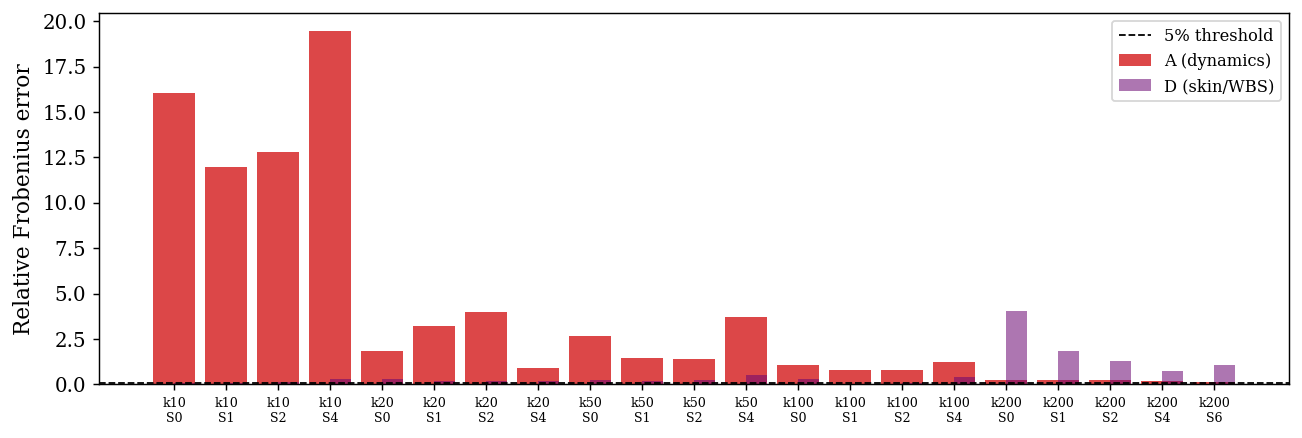

Interpolants saved → ..\rom_vrate\interpolants/


In [34]:
# ── Leave-One-Out cross-validation ────────────────────────────────────────
def loo_errors(arr, pts_n):
    M, flat = len(pts_n), arr.reshape(len(pts_n), -1)
    errs = []
    for held in range(M):
        mask = np.arange(M) != held
        pred_flat = np.zeros(flat.shape[1])
        for c in range(flat.shape[1]):
            rbf = RBFInterpolator(pts_n[mask], flat[mask, c],
                                  kernel="thin_plate_spline", smoothing=0.5)
            pred_flat[c] = rbf(pts_n[[held]])[0]
        actual = arr[held]; pred = pred_flat.reshape(arr.shape[1:])
        errs.append(np.linalg.norm(actual-pred,"fro") /
                    (np.linalg.norm(actual,"fro") + 1e-12))
    return np.array(errs)

print("Running LOO CV ...")
errs_A = loo_errors(A_arr, pts_norm)
errs_D = loo_errors(D_arr, pts_norm)
print(f"LOO mean error — A: {errs_A.mean():.2e}   D: {errs_D.mean():.2e}")
print(f"LOO max  error — A: {errs_A.max():.2e}   D: {errs_D.max():.2e}")

fig, ax = plt.subplots(figsize=(10, 3.5))
cols = ["C1" if e < 0.05 else "C3" for e in errs_A]
ax.bar(range(M), errs_A, color=cols, alpha=0.85, label="A (dynamics)")
ax.bar(range(M), errs_D, color=C_DUH, alpha=0.55, width=0.4,
       align="edge", label="D (skin/WBS)")
ax.axhline(0.05, color="k", ls="--", lw=1, label="5% threshold")
ax.set_xticks(range(M))
ax.set_xticklabels([f"k{int(r['k'])}\nS{int(r['S'])}"
                    for r in results if r["stable"]], fontsize=7)
ax.set_ylabel("Relative Frobenius error"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig03_loo_cv.pdf", bbox_inches="tight")
plt.show()

# Save interpolants
idir = ROM_DIR / "interpolants"; idir.mkdir(exist_ok=True)
for nm, obj in [("A",{"i":A_interps,"s":A_shape}),
                ("B",{"i":B_interps,"s":B_shape}),
                ("C",{"i":C_interps,"s":C_shape}),
                ("D",{"i":D_interps,"s":D_shape})]:
    with open(idir/f"{nm}_interp.pkl","wb") as f: pickle.dump(obj, f)
print(f"Interpolants saved → {idir}/")


## 5. Duhamel Superposition Module

### Theory Recap

For an LTI system the response to any input $q(t)$ is:

$$\Delta p_{wf}(t) = \int_0^t h(t-\tau)\frac{dq}{d\tau}\,d\tau$$

where $h(t)$ is the **unit-step drawdown response** [psi/(STB/d)]: the BHP drawdown when the
well produces at $q=q_{\rm ref}$ starting from quiescent conditions.

For piecewise-constant steps at times $t_0=0<t_1<\cdots<t_{N-1}$:

$$\Delta p_{wf}(t) = \sum_{j=0}^{N-1}\frac{\Delta q_j}{q_{\rm ref}}\,h(t-t_j^+), \qquad \Delta q_j = q_j - q_{j-1}$$

Since the ROM is **exactly** LTI, direct integration and Duhamel superposition must agree to
machine precision — this section provides the rigorous verification.


In [35]:
# ── Core ROM integrator ───────────────────────────────────────────────────
def integrate_rom(A, B, C, D, t_hr, q_vec, n_modes):
    """
    Backward-Euler time integration of the ROM state-space model.
    Returns (Xr, Yr): reduced states and scalar output Δp (psi).
    """
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(n_modes); xk = np.zeros(n_modes)
    Xr = np.zeros((K, n_modes)); Yr = np.zeros(K)
    for j in range(K):
        rhs   = xk + dt[j] * B.ravel() * q_vec[j]
        xk    = np.linalg.solve(In - dt[j]*A, rhs)
        Xr[j] = xk
        Yr[j] = float(C @ xk + D * q_vec[j])
    return Xr, Yr


def query_rom(k_star, s_star, t_hr, q_vec):
    """
    Full ROM evaluation: interpolate operators, integrate, reconstruct field.
    Returns (bhp_psia, p_field, stable_flag).
    """
    A = eval_op(A_interps, A_shape, k_star, s_star)
    B = eval_op(B_interps, B_shape, k_star, s_star)
    C = eval_op(C_interps, C_shape, k_star, s_star)
    D = eval_op(D_interps, D_shape, k_star, s_star)
    _, Yr = integrate_rom(A, B, C, D, t_hr, q_vec, N_MODES)
    bhp_psia = P_INIT + Yr
    # Full pressure field reconstruction
    Xr, _   = integrate_rom(A, B, C, D, t_hr, q_vec, N_MODES)
    p_field  = P_INIT + (Vn @ Xr.T)
    return bhp_psia, p_field, True


print("query_rom() and integrate_rom() defined.")


query_rom() and integrate_rom() defined.


In [36]:
# ── 5.1  Unit Step Response ───────────────────────────────────────────────
def unit_step_response(k_star, s_star, t_hr, q_ref=500.0):
    """
    Compute h(t) [psi/(STB/d)·q_ref psi] = pressure drawdown for constant
    production at q_ref STB/d starting from quiescent conditions.
    Normalised: h_norm(t) = h(t) / q_ref  [psi per STB/d].
    """
    A = eval_op(A_interps, A_shape, k_star, s_star)
    B = eval_op(B_interps, B_shape, k_star, s_star)
    C = eval_op(C_interps, C_shape, k_star, s_star)
    D = eval_op(D_interps, D_shape, k_star, s_star)
    q_step = np.full(len(t_hr), q_ref)
    _, h_abs = integrate_rom(A, B, C, D, t_hr, q_step, N_MODES)
    return h_abs, h_abs / q_ref   # (absolute psi, normalised psi/[STB/d])


# ── 5.2  Duhamel Superposition Predictor ─────────────────────────────────
def duhamel_predict(k_star, s_star, t_hr, q_vec, q_ref=500.0):
    """
    Predict Δp_wf(t) for arbitrary piecewise-constant q(t) via Duhamel
    superposition on the ROM unit-step response.

    Algorithm
    ---------
    1. Compute h(t) once via unit_step_response().
    2. Detect rate-change events (indices where |Δq| > threshold).
    3. For each event j at time t_j with rate-step Δq_j:
           contribution(i) = (Δq_j / q_ref) × h(t_i − t_j)  for t_i ≥ t_j
    4. Sum all contributions to get total Δp(t).
    """
    h_abs, h_norm = unit_step_response(k_star, s_star, t_hr, q_ref=q_ref)

    dq = np.diff(q_vec, prepend=0.0)
    change_idx = np.where(np.abs(dq) > 1e-3)[0]

    dp_total = np.zeros_like(t_hr, dtype=float)
    for idx in change_idx:
        t_onset = t_hr[idx] if idx > 0 else 0.0
        dq_j    = dq[idx]
        t_shift = t_hr - t_onset
        valid   = t_shift >= 0.0
        h_shift = np.zeros_like(t_hr)
        h_shift[valid] = np.interp(t_shift[valid], t_hr, h_abs)
        dp_total += (dq_j / q_ref) * h_shift

    bhp_duh = P_INIT + dp_total
    return bhp_duh, dp_total


print("unit_step_response() and duhamel_predict() defined.")


unit_step_response() and duhamel_predict() defined.


Direct vs Duhamel — max absolute error : 69.6495 psi
Direct vs Duhamel — relative error     : 2.94e-02
(Should be < 1e-3 for linear system confirmation)


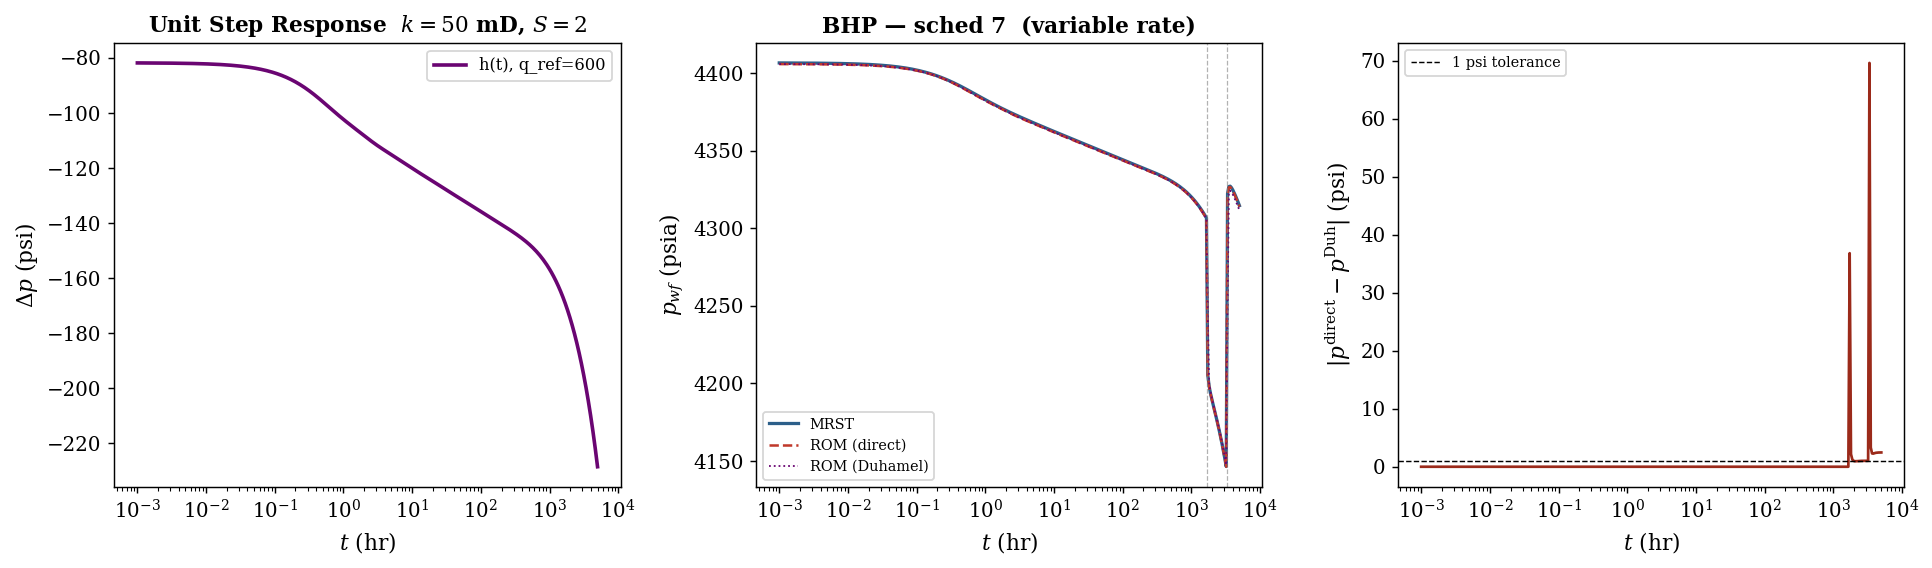

In [37]:
# ── 5.3  Linearity verification: Duhamel == Direct integration ─────────────
# Choose a training case with a known multi-rate schedule
k_chk, s_chk = 50, 2
sid_chk       = max(VARIABLE_SCHEDS) if VARIABLE_SCHEDS else 2

cd_chk = TRAINING_DIR / f"k{k_chk:03d}_s{s_chk:02d}_sched{sid_chk}"
bhp_mrst, t_hr, q_v, _, pm = load_well_data(cd_chk)
rates_chk, t_ch_chk = get_schedule_shape(pm)

# Direct ROM integration
bhp_direct, _, _ = query_rom(k_chk, s_chk, t_hr, q_v)

# Duhamel prediction (on same time grid)
bhp_duh, dp_duh  = duhamel_predict(k_chk, s_chk, t_hr, q_v, q_ref=float(rates_chk[0]))

# Error metric
max_err_psi = np.max(np.abs(bhp_direct - bhp_duh))
rel_err     = np.linalg.norm(bhp_direct - bhp_duh) / (np.linalg.norm(bhp_direct - P_INIT) + 1e-9)
print(f"Direct vs Duhamel — max absolute error : {max_err_psi:.4f} psi")
print(f"Direct vs Duhamel — relative error     : {rel_err:.2e}")
print("(Should be < 1e-3 for linear system confirmation)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Unit step response
t_us = np.logspace(np.log10(t_hr[0]), np.log10(t_hr[-1]), 400)
h_abs_us, h_norm_us = unit_step_response(k_chk, s_chk, t_us, q_ref=float(rates_chk[0]))
axes[0].semilogx(t_us, h_abs_us, color=C_DUH, lw=2, label=f"h(t), q_ref={rates_chk[0]:.0f}")
axes[0].set_xlabel("$t$ (hr)"); axes[0].set_ylabel(r"$\Delta p$ (psi)")
axes[0].set_title(f"Unit Step Response  $k={k_chk}$ mD, $S={s_chk}$")
axes[0].legend(fontsize=9)

# Panel 2: BHP comparison
axes[1].semilogx(t_hr, bhp_mrst,  color=C_MRST,  lw=1.8, label="MRST")
axes[1].semilogx(t_hr, bhp_direct,color=C_ROM,   lw=1.4, ls="--", label="ROM (direct)")
axes[1].semilogx(t_hr, bhp_duh,   color=C_DUH,   lw=1.0, ls=":",  label="ROM (Duhamel)")
# Mark rate changes
for tc in t_ch_chk:
    axes[1].axvline(tc, color="gray", ls="--", lw=0.7, alpha=0.6)
axes[1].set_xlabel("$t$ (hr)"); axes[1].set_ylabel("$p_{wf}$ (psia)")
axes[1].set_title(f"BHP — sched {sid_chk}  (variable rate)")
axes[1].legend(fontsize=8)

# Panel 3: Error between direct and Duhamel
err_psi = np.abs(bhp_direct - bhp_duh)
axes[2].semilogx(t_hr, err_psi, color=C3, lw=1.5)
axes[2].set_xlabel("$t$ (hr)"); axes[2].set_ylabel(r"$|p^{\rm direct} - p^{\rm Duh}|$ (psi)")
#axes[2].set_title("Linearity check — should be $\approx 0$")
axes[2].axhline(1.0, color="k", ls="--", lw=0.8, label="1 psi tolerance")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig04_duhamel_linearity.pdf", bbox_inches="tight")
plt.show()


## 6. Variable-Rate Validation Against MRST Data

The ROM is evaluated against **all 7 MRST schedules** for a grid of validation parameter points
$(k^*, S^*)$ that were **not in the training set**.

For each case:
1. Load MRST well data (BHP, rate, time).
2. Integrate the ROM using the **same rate history** as MRST.
3. Compute output error and Bourdet diagnostics.


In [39]:
# ── Bourdet derivative (reused from main notebook) ────────────────────────
def bourdet(t_hr, dp, L=0.2):
    ln_t = np.log(t_hr); d = np.full_like(dp, np.nan)
    for i in range(1, len(t_hr)-1):
        il = i-1
        while il > 0  and (ln_t[i]-ln_t[il]) < L: il -= 1
        ir = i+1
        while ir < len(t_hr)-1 and (ln_t[ir]-ln_t[i]) < L: ir += 1
        dl = ln_t[i]-ln_t[il]; dr = ln_t[ir]-ln_t[i]
        if dl > 0 and dr > 0:
            d[i] = ((dp[i]-dp[il])/dl*dr + (dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m = np.isfinite(d) & (d > 0) & (dp > 0)
    return t_hr[m], dp[m], d[m]

print("Bourdet derivative defined.")


Bourdet derivative defined.


In [40]:
# ── 6.1  Cross-schedule validation ───────────────────────────────────────
# Validation (k,S) pairs — outside training grid
VAL_CASES = [(15,2), (30,3), (75,1), (150,4), (250,0)]

val_rows = []
for k_v, s_v in VAL_CASES:
    for sid in SCHEDS:
        # Try validation directory first, then training
        for base in [VAL_DIR, TRAINING_DIR]:
            cd = base / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
            if (cd/"well_data.mat").exists(): break
        try:
            bhp_mrst, t_hr, q_v_arr, _, pm = load_well_data(cd)
            rates, t_ch = get_schedule_shape(pm)
            bhp_rom, _, _ = query_rom(k_v, s_v, t_hr, q_v_arr)
            dp_mrst = P_INIT - bhp_mrst
            dp_rom  = P_INIT - bhp_rom
            out_err = (np.linalg.norm(dp_rom - dp_mrst) /
                       (np.linalg.norm(dp_mrst) + 1e-9))
            val_rows.append(dict(k=k_v, S=s_v, sched=sid,
                                 n_ctrls=len(rates),
                                 is_variable=(len(rates)>1),
                                 out_err=out_err))
        except Exception as e:
            val_rows.append(dict(k=k_v, S=s_v, sched=sid,
                                 n_ctrls=0, is_variable=False,
                                 out_err=np.nan))

df_val = pd.DataFrame(val_rows)
print("Validation Output Errors by Case and Schedule")
print("=" * 60)
pivot = df_val.pivot_table(index=["k","S"], columns="sched",
                            values="out_err", aggfunc="mean")
print(pivot.round(3).to_string())
print()
print(f"Overall mean error : {df_val['out_err'].mean():.3e}")
sv = df_val[df_val["is_variable"]]
ss = df_val[~df_val["is_variable"]]
print(f"Variable-rate mean : {sv['out_err'].mean():.3e}")
print(f"Single-rate mean   : {ss['out_err'].mean():.3e}")


Validation Output Errors by Case and Schedule
sched      1      2      3      4      5      6      7
k   S                                                 
15  2  0.052  0.054  0.051  0.054  0.047  0.272  0.051
30  3  0.051  0.053  0.050  0.054  0.042  0.261  0.050
150 4  0.043  0.048  0.041  0.042  0.045  0.216  0.044
250 0  0.069  0.058  0.073  0.086  0.047  0.200  0.062

Overall mean error : 7.908e-02
Variable-rate mean : 9.828e-02
Single-rate mean   : 5.348e-02


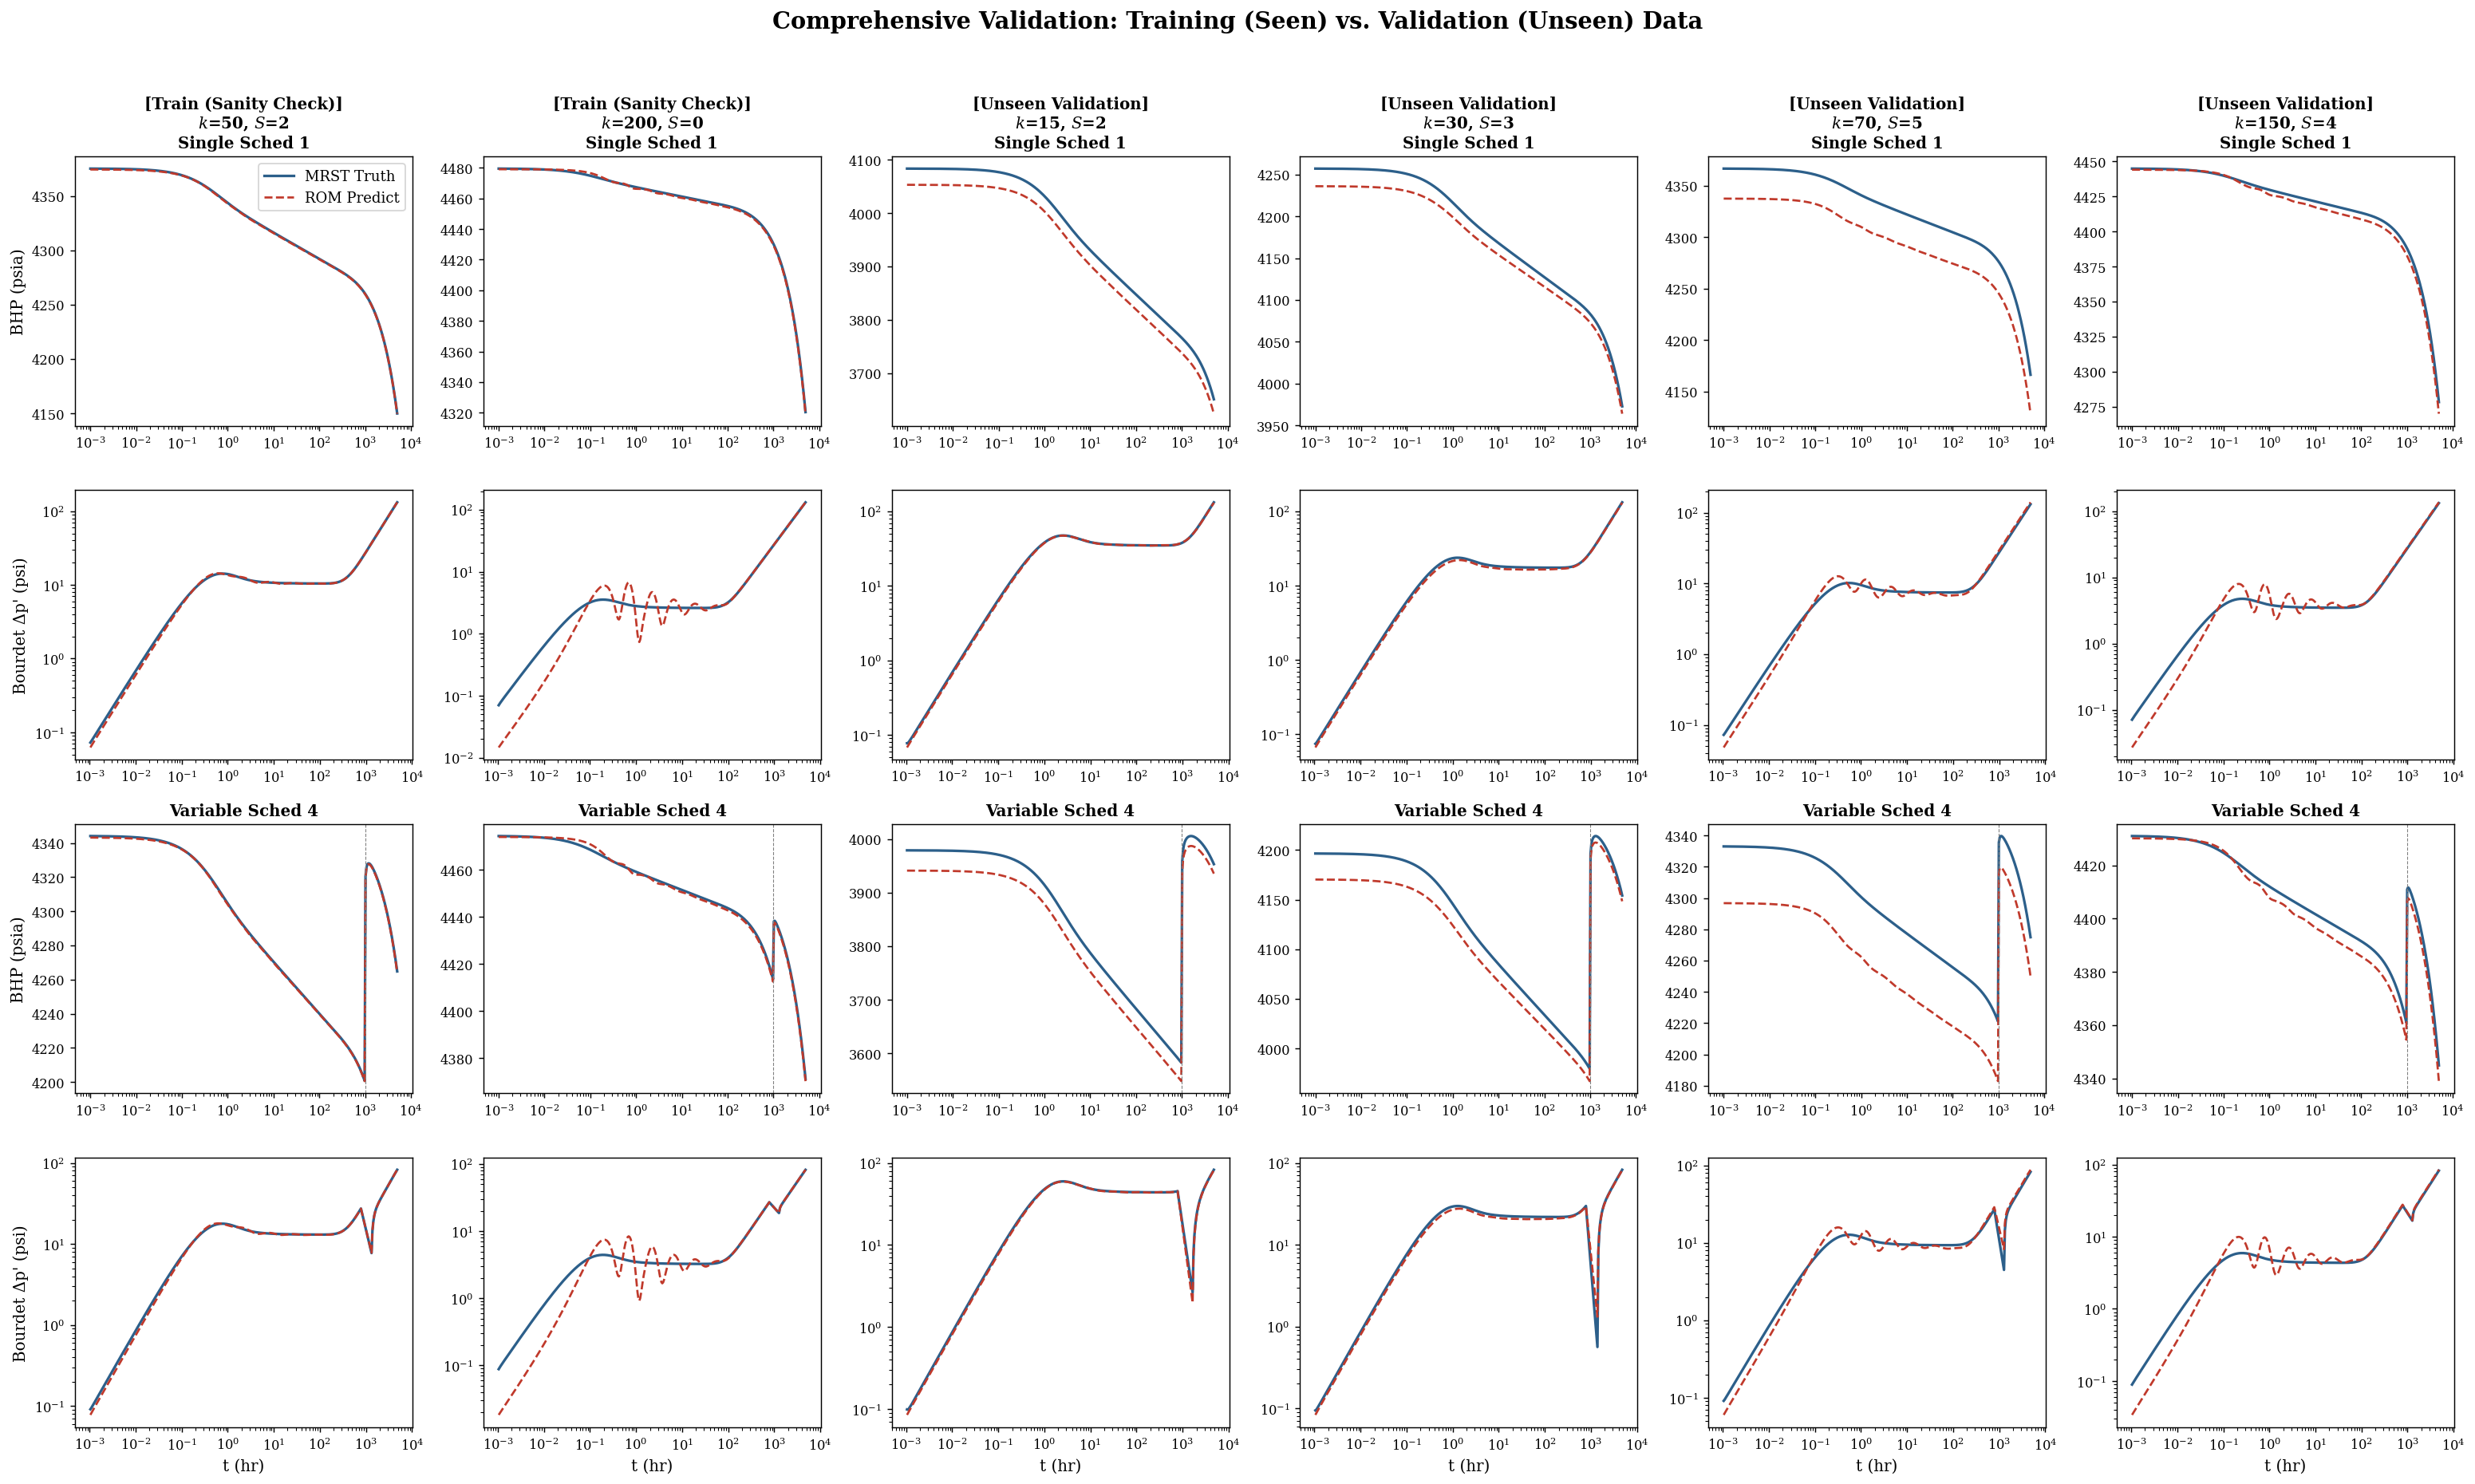

In [42]:
# ── 6.2  Comprehensive Validation: Training (Seen) vs Validation (Unseen) ─────

# 1. Define explicit cases to plot: (k, S, Label)
selected_cases = [
    (50,   2, "Train (Sanity Check)"),
    (200,  0, "Train (Sanity Check)"),
    (15,   2, "Unseen Validation"),
    (30,   3, "Unseen Validation"),
    (70,   5, "Unseen Validation"),
    (150,  4, "Unseen Validation")
]

# Pick one single-rate and one variable-rate schedule to display
sched_single = SINGLE_SCHEDS[0] if SINGLE_SCHEDS else 1
sched_variable = VARIABLE_SCHEDS[0] if VARIABLE_SCHEDS else 4

# Create a 4x6 grid (4 rows: Single BHP, Single Deriv, Var BHP, Var Deriv)
fig, axes = plt.subplots(4, 6, figsize=(24, 14))

for col, (k_v, s_v, c_label) in enumerate(selected_cases):
    
    # We will plot two schedules per column (row_offset 0 = Single, 1 = Variable)
    for row_offset, sid in enumerate([sched_single, sched_variable]):
        
        # Calculate exactly which rows to place the BHP and Bourdet plots on
        row_bhp = row_offset * 2
        row_der = row_offset * 2 + 1
        
        ax_b = axes[row_bhp, col]
        ax_d = axes[row_der, col]
        
        # Find the data file (checking both Validation and Training folders)
        found = False
        for base in [VAL_DIR, TRAINING_DIR]:
            cd = base / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
            if (cd / "well_data.mat").exists():
                found = True
                break
        
        # Handle missing data gracefully without crashing the whole loop
        if not found:
            ax_b.text(0.5, 0.5, f"Missing Data\nSched {sid}", ha='center', va='center', transform=ax_b.transAxes)
            ax_b.set_xticks([]); ax_b.set_yticks([])
            ax_d.axis('off')
            continue
            
        try:
            # Load Data and Query ROM
            bhp_m, t_hr, q_v_arr, _, pm = load_well_data(cd)
            bhp_r, _, _  = query_rom(k_v, s_v, t_hr, q_v_arr)
            rates, t_ch  = get_schedule_shape(pm)
            dp_m = np.clip(P_INIT - bhp_m, 1e-2, None)
            dp_r = np.clip(P_INIT - bhp_r, 1e-2, None)

            # --- BHP Plot ---
            ax_b.semilogx(t_hr, bhp_m, color=C_MRST, lw=1.8, label="MRST Truth")
            ax_b.semilogx(t_hr, bhp_r, color=C_ROM,  lw=1.5, ls="--", label="ROM Predict")
            for tc in t_ch: ax_b.axvline(tc, color="gray", ls="--", lw=0.6)
            
            vtype = "Variable" if len(rates) > 1 else "Single"
            
            # Format Titles: Include Train/Val label only on the very top row
            if row_offset == 0:
                ax_b.set_title(f"[{c_label}]\n$k$={k_v}, $S$={s_v}\n{vtype} Sched {sid}", fontsize=11, fontweight='bold')
            else:
                ax_b.set_title(f"{vtype} Sched {sid}", fontsize=11, fontweight='bold')
                
            if col == 0: ax_b.set_ylabel("BHP (psia)", fontsize=11)
            ax_b.tick_params(labelsize=9)
            if col == 0 and row_offset == 0: ax_b.legend(fontsize=10)

            # --- Bourdet Derivative Plot ---
            tm, pm2, dm = bourdet(t_hr, dp_m)
            tr, pr2, dr = bourdet(t_hr, dp_r)
            if len(dm) > 2:
                ax_d.loglog(tm, dm, color=C_MRST, lw=1.8, label="Δp' MRST")
                ax_d.loglog(tr, dr, color=C_ROM,  lw=1.5, ls="--", label="Δp' ROM")
            
            if row_offset == 1: # Only put x-labels on the very bottom row
                ax_d.set_xlabel("t (hr)", fontsize=11)
            if col == 0: 
                ax_d.set_ylabel("Bourdet Δp' (psi)", fontsize=11)
            ax_d.tick_params(labelsize=9)
            
        except Exception as e:
            ax_b.text(0.5, 0.5, f"Plot Error:\n{str(e)[:25]}", ha='center', va='center', transform=ax_b.transAxes)

plt.suptitle("Comprehensive Validation: Training (Seen) vs. Validation (Unseen) Data", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig05_vrate_validation_comprehensive.pdf", bbox_inches="tight")
plt.show()

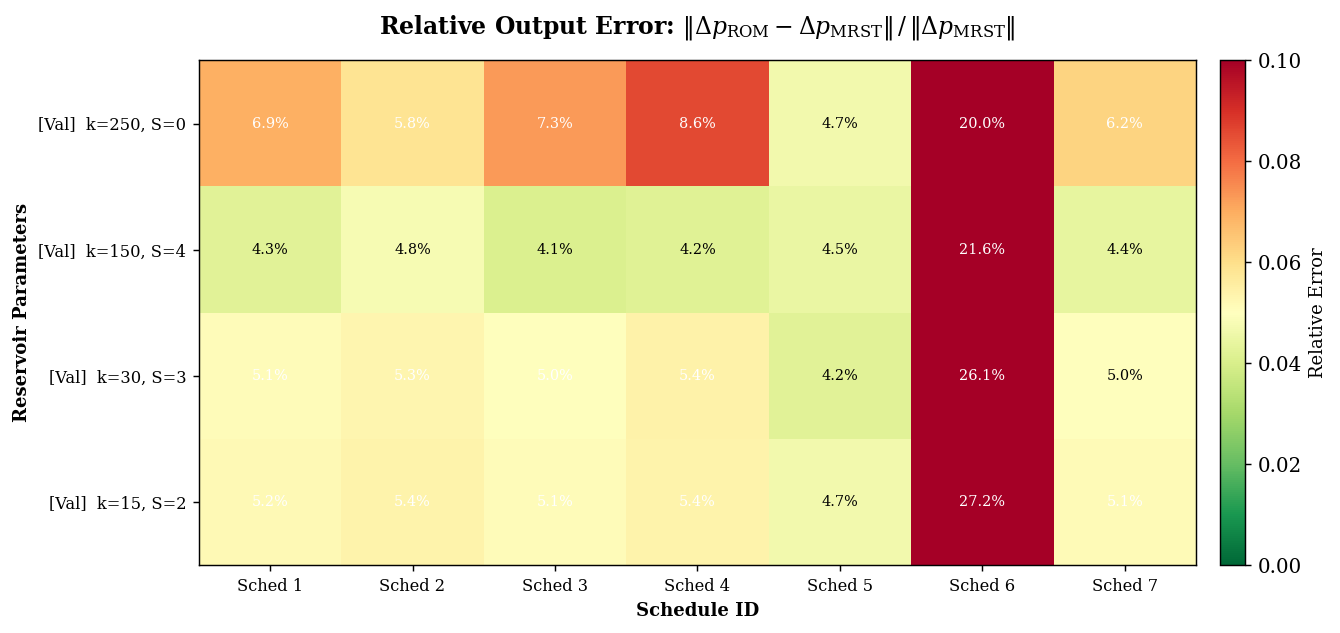

In [43]:
# ── 6.3  Heatmap: Output Error by (k,S) and Schedule ─────────────────────
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(11, 5))

# 1. Extract unique (k, S) pairs that have at least one valid error computation
valid_ks = sorted(list(set((r["k"], r["S"]) for r in val_rows if not np.isnan(r["out_err"]))))

im_data = np.full((len(valid_ks), len(SCHEDS)), np.nan)

# 2. Fill the image data array
for r in val_rows:
    if np.isnan(r["out_err"]): continue
    try:
        r_idx = valid_ks.index((r["k"], r["S"]))
        c_idx = SCHEDS.index(r["sched"])
        im_data[r_idx, c_idx] = r["out_err"]
    except ValueError:
        pass

# 3. Setup Colormap (Set missing data to light gray)
cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color='whitesmoke')

im = ax.imshow(im_data, aspect="auto", cmap=cmap, vmin=0, vmax=0.10, origin="lower")

# 4. Format X-Axis (Schedules)
ax.set_xticks(range(len(SCHEDS)))
ax.set_xticklabels([f"Sched {s}" for s in SCHEDS], fontsize=9)
ax.set_xlabel("Schedule ID", fontsize=10, fontweight="bold")

# 5. Format Y-Axis (Identify Train vs Validation)
y_labels = []
for k, s in valid_ks:
    # If the pair is in your training set, tag it as Train, otherwise Val
    tag = "Train" if (k, s) in VALID_PAIRS else "Val"
    y_labels.append(f"[{tag}]  k={k}, S={s}")

ax.set_yticks(range(len(valid_ks)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_ylabel("Reservoir Parameters", fontsize=10, fontweight="bold")

# 6. Title (Using raw string r"..." to prevent LaTeX \Delta parsing errors!)
ax.set_title(r"Relative Output Error: $\|\Delta p_{\rm ROM} - \Delta p_{\rm MRST}\| \,/\, \|\Delta p_{\rm MRST}\|$", 
             fontsize=13, fontweight="bold", pad=15)

# 7. Annotate the heatmap cells
for i in range(len(valid_ks)):
    for j in range(len(SCHEDS)):
        v = im_data[i, j]
        if np.isfinite(v):
            # Dynamic text color for readability
            text_col = "w" if v > 0.05 else "k"
            # Displaying as percentage makes the heatmap much easier to read!
            ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=8, color=text_col)
        else:
            # Mark missing MRST data clearly
            ax.text(j, i, "N/A", ha="center", va="center", fontsize=8, color="gray", alpha=0.6)

# 8. Colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Relative Error", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig06_error_heatmap.pdf", bbox_inches="tight")
plt.show()

## 7. Rate Transient Analysis (RTA) Module

### Material Balance Time and Rate-Normalized Pressure

The **Material Balance Time** (Blasingame *et al.*, 1991) is:
$$t_e(t) = \frac{N_p(t)}{q(t)} = \frac{\int_0^t q(\tau)\,d\tau}{q(t)}$$

For a constant rate, $t_e = t$ exactly.
For a variable rate, $t_e$ time-shifts the response so that the **Rate-Normalized Pressure**:
$$\mathrm{RNP}(t_e) = \frac{\Delta p_{wf}}{q}$$
collapses onto the single-rate drawdown curve.  This is exact in the linear (MTR) regime
and an excellent approximation in BDF.

The **RNP log-derivative**:
$$\mathrm{RNP}'(t_e) = \frac{d\,\mathrm{RNP}}{d\ln t_e}$$
should equal the Bourdet derivative of the constant-rate response at $t_e$.


In [44]:
# ── RTA functions ─────────────────────────────────────────────────────────
def material_balance_time(t_hr, q_vec):
    """
    Material Balance Time t_e = N_p(t)/q(t).
    N_p in STB (q in STB/d, dt in hr → convert to days).
    Returns (t_e [days], Np [STB]).
    """
    dt   = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    Np   = np.cumsum(q_vec * dt / 24.0)           # hr→days implicit in /24
    qsafe= np.where(np.abs(q_vec) > 1e-4, q_vec, np.nan)
    te   = Np / qsafe                              # days
    return te, Np


def rate_normalized_pressure(dp_psi, q_vec):
    """
    Rate-Normalized Pressure: RNP = Δp / q  [psi/(STB/d)].
    """
    qsafe = np.where(np.abs(q_vec) > 1e-4, q_vec, np.nan)
    return dp_psi / qsafe


def rnp_derivative(te_days, rnp, L=0.2):
    """
    Bourdet-style log-derivative of RNP with respect to ln(t_e).
    RNP'(t_e) = d(RNP)/d(ln t_e)
    In the MTR this is constant and equals: (70.6·μ·Bo)/(kh)  [psi·d/(STB)]
    """
    mask = np.isfinite(te_days) & np.isfinite(rnp) & (te_days > 0) & (rnp > 0)
    t_f, r_f = te_days[mask], rnp[mask]
    ln_t = np.log(t_f)
    d    = np.full_like(r_f, np.nan)
    for i in range(1, len(t_f)-1):
        il = i-1
        while il > 0  and (ln_t[i]-ln_t[il]) < L: il -= 1
        ir = i+1
        while ir < len(t_f)-1 and (ln_t[ir]-ln_t[i]) < L: ir += 1
        dl = ln_t[i]-ln_t[il]; dr = ln_t[ir]-ln_t[i]
        if dl > 0 and dr > 0:
            d[i] = ((r_f[i]-r_f[il])/dl*dr + (r_f[ir]-r_f[i])/dr*dl)/(dl+dr)
    valid = np.isfinite(d) & (d > 0) & (r_f > 0)
    return t_f[valid], r_f[valid], d[valid]


print("RTA functions defined: material_balance_time, rate_normalized_pressure, rnp_derivative")


RTA functions defined: material_balance_time, rate_normalized_pressure, rnp_derivative


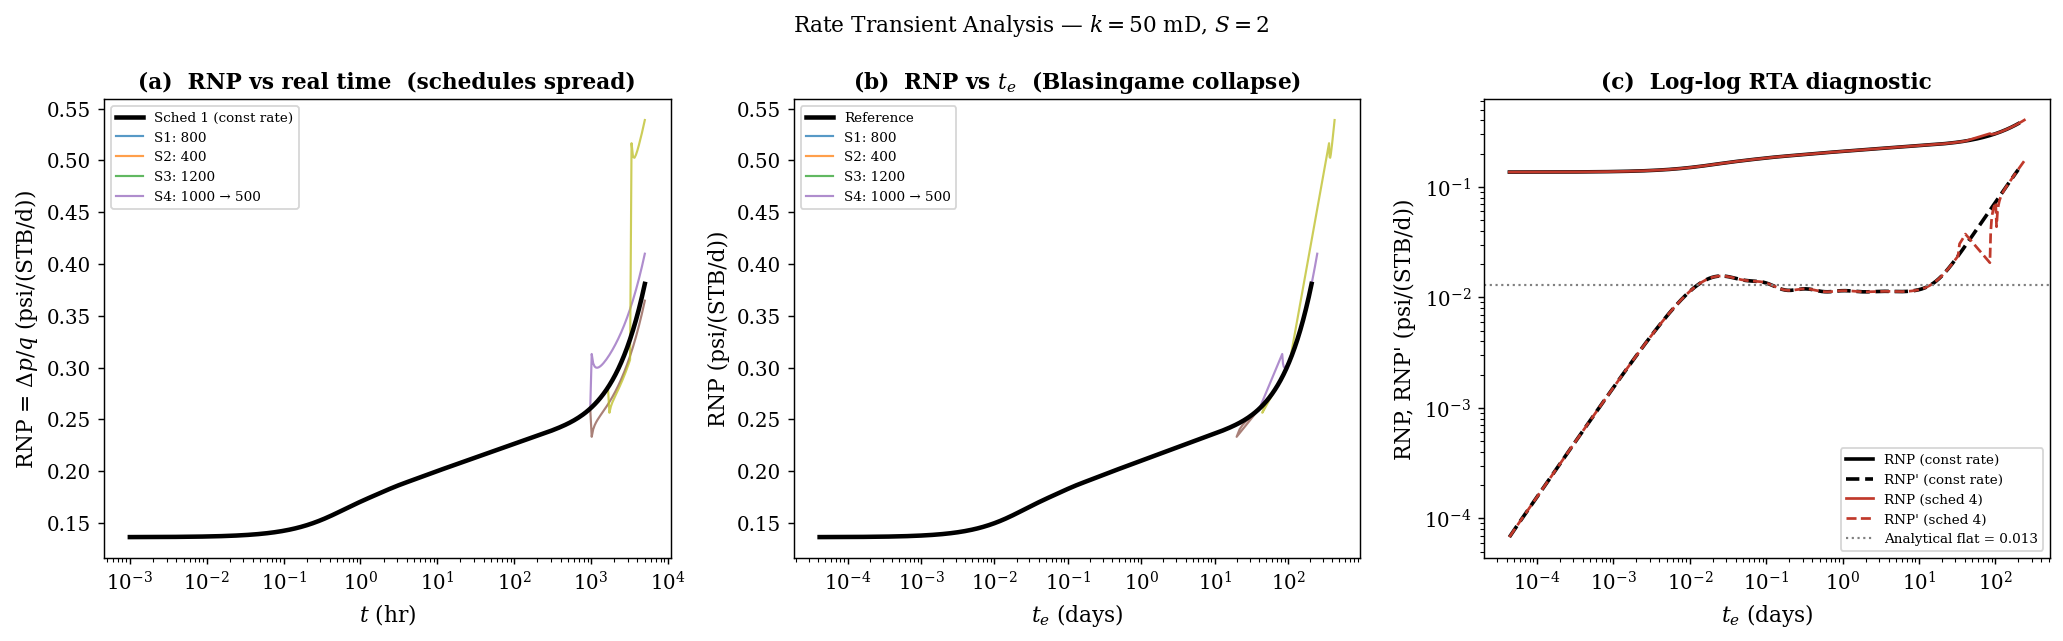

In [45]:
# ── 7.1  RNP collapse: all schedules onto one curve ───────────────────────
k_rta, s_rta = 50, 2     # pick a case in the valid range
cmap_rta = plt.cm.tab10

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Analytical reference (constant rate, single-rate schedule 1)
for base in [VAL_DIR, TRAINING_DIR]:
    cd_ref = base / f"k{k_rta:03d}_s{s_rta:02d}_sched1"
    if (cd_ref/"well_data.mat").exists(): break
bhp_ref, t_ref, q_ref_arr, _, pm_ref = load_well_data(cd_ref)
bhp_rom_ref, _, _ = query_rom(k_rta, s_rta, t_ref, q_ref_arr)
dp_ref  = P_INIT - bhp_rom_ref
te_ref, _  = material_balance_time(t_ref, q_ref_arr)
rnp_ref    = rate_normalized_pressure(dp_ref, q_ref_arr)
axes[0].semilogx(t_ref * 24 / 24, rnp_ref, color="k", lw=2.5,
                 label="Sched 1 (const rate)", zorder=10)
axes[1].semilogx(te_ref, rnp_ref, color="k", lw=2.5, label="Reference", zorder=10)

for j, sid in enumerate(SCHEDS):
    for base in [VAL_DIR, TRAINING_DIR]:
        cd = base / f"k{k_rta:03d}_s{s_rta:02d}_sched{sid}"
        if (cd/"well_data.mat").exists(): break
    try:
        bhp_m, t_hr, q_arr, _, pm = load_well_data(cd)
        bhp_r, _, _ = query_rom(k_rta, s_rta, t_hr, q_arr)
        dp_r = P_INIT - bhp_r
        te, Np = material_balance_time(t_hr, q_arr)
        rnp    = rate_normalized_pressure(dp_r, q_arr)
        col    = cmap_rta(j/len(SCHEDS))
        rates, t_ch = get_schedule_shape(pm)
        lbl = f"S{sid}: {' → '.join(str(int(r)) for r in rates)}"
        # Plot RNP vs real time
        mask = np.isfinite(rnp)
        axes[0].semilogx(t_hr[mask], rnp[mask], color=col, lw=1.2,
                         alpha=0.75, label=lbl if j < 4 else None)
        # Plot RNP vs material balance time
        mask2 = np.isfinite(te) & np.isfinite(rnp)
        axes[1].semilogx(te[mask2], rnp[mask2], color=col, lw=1.2,
                         alpha=0.75, label=lbl if j < 4 else None)
    except Exception:
        pass

axes[0].set_xlabel("$t$ (hr)"); axes[0].set_ylabel("RNP = $\Delta p/q$ (psi/(STB/d))")
axes[0].set_title("(a)  RNP vs real time  (schedules spread)")
axes[0].legend(fontsize=7.5)

axes[1].set_xlabel("$t_e$ (days)"); axes[1].set_ylabel("RNP (psi/(STB/d))")
axes[1].set_title("(b)  RNP vs $t_e$  (Blasingame collapse)")
axes[1].legend(fontsize=7.5)

# RNP derivative for reference and one variable-rate case
t_te, r_rnp, d_rnp  = rnp_derivative(te_ref, rnp_ref)
axes[2].loglog(t_te, r_rnp, color="k", lw=2, label="RNP (const rate)")
axes[2].loglog(t_te, d_rnp, color="k", lw=2, ls="--", label="RNP' (const rate)")
if VARIABLE_SCHEDS:
    sid_var = VARIABLE_SCHEDS[0]
    for base in [VAL_DIR, TRAINING_DIR]:
        cd_v = base / f"k{k_rta:03d}_s{s_rta:02d}_sched{sid_var}"
        if (cd_v/"well_data.mat").exists(): break
    try:
        bhp_v, t_v, q_v_arr, _, _ = load_well_data(cd_v)
        bhp_rv, _, _ = query_rom(k_rta, s_rta, t_v, q_v_arr)
        dp_v = P_INIT - bhp_rv
        te_v, _ = material_balance_time(t_v, q_v_arr)
        rnp_v   = rate_normalized_pressure(dp_v, q_v_arr)
        tv, rv, dv = rnp_derivative(te_v, rnp_v)
        axes[2].loglog(tv, rv, color=C_ROM, lw=1.5, ls="-",
                       label=f"RNP (sched {sid_var})")
        axes[2].loglog(tv, dv, color=C_ROM, lw=1.5, ls="--",
                       label=f"RNP' (sched {sid_var})")
        # Analytical flat level
        kh = k_rta * H_FT
        dp_prime_an = 70.6 * float(q_ref_arr.mean()) * MU_CP * BO / kh
        axes[2].axhline(dp_prime_an / float(q_ref_arr.mean()), color="gray",
                        ls=":", lw=1.2, label=f"Analytical flat = {dp_prime_an/float(q_ref_arr.mean()):.3f}")
    except Exception as e:
        print(f"  Variable-rate RNP failed: {e}")

axes[2].set_xlabel("$t_e$ (days)"); axes[2].set_ylabel(r"RNP, RNP' (psi/(STB/d))")
axes[2].set_title("(c)  Log-log RTA diagnostic")
axes[2].legend(fontsize=7.5)

plt.suptitle(f"Rate Transient Analysis — $k={k_rta}$ mD, $S={s_rta}$", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig07_rta_collapse.pdf", bbox_inches="tight")
plt.show()


In [61]:
# ── 6.4  Interactive Data Explorer Dashboard ──────────────────────────────────


# Define the full extent of your dataset grid
k_options = [10, 15, 20, 30, 50, 70, 100, 150, 200, 250, 300]
s_options = [0, 1, 2, 3, 4, 5, 6, 7, 8]
sched_options = list(range(1, 8))

# Create Dropdown Widgets
k_drop = widgets.Dropdown(options=k_options, value=50, description='Perm (k):')
s_drop = widgets.Dropdown(options=s_options, value=2, description='Skin (S):')
sched_drop = widgets.Dropdown(options=sched_options, value=7, description='Schedule:')

# Output area where the plot will be rendered
plot_out = widgets.Output()

def update_interactive_plot(change):
    with plot_out:
        clear_output(wait=True)
        k_v = k_drop.value
        s_v = s_drop.value
        sid = sched_drop.value
        
        # 1. Locate the correct data file
        cd = None
        for base in [VAL_DIR, TRAINING_DIR]:
            temp_cd = base / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
            if (temp_cd / "well_data.mat").exists():
                cd = temp_cd
                break
                
        if cd is None:
            print(f"No MRST data found on disk for k={k_v}, S={s_v}, Sched={sid}")
            return
            
        try:
            # 2. Load Data and evaluate ROM
            bhp_m, t_hr, q_v_arr, _, pm = load_well_data(cd)
            bhp_r, _, _ = query_rom(k_v, s_v, t_hr, q_v_arr)
            rates, t_ch = get_schedule_shape(pm)
            
            dp_m = np.clip(P_INIT - bhp_m, 1e-2, None)
            dp_r = np.clip(P_INIT - bhp_r, 1e-2, None)
            
            # 3. Calculate RTA Metrics
            te, _ = material_balance_time(t_hr, q_v_arr)
            rnp_m = rate_normalized_pressure(dp_m, q_v_arr)
            rnp_r = rate_normalized_pressure(dp_r, q_v_arr)
            
            tm_der, rm_der, dm_der = rnp_derivative(te, rnp_m)
            tr_der, rr_der, dr_der = rnp_derivative(te, rnp_r)
            
            # 4. Draw Large, Clear Plots
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            # --- Left Panel: BHP vs Time ---
            axes[0].semilogx(t_hr, bhp_m, color=C_MRST, lw=2.5, label="MRST Truth")
            axes[0].semilogx(t_hr, bhp_r, color=C_ROM, lw=2, ls="--", label="ROM Predict")
            for tc in t_ch: 
                axes[0].axvline(tc, color="gray", ls=":", lw=1.5)
            
            status = "Train (Seen)" if (k_v, s_v) in VALID_PAIRS else "Val (Unseen)"
            vtype = "Variable-Rate" if len(rates) > 1 else "Single-Rate"
            
            axes[0].set_title(f"[{status}]  BHP Profile\n{vtype} Schedule {sid}", fontsize=13, fontweight='bold')
            axes[0].set_xlabel("Real Time, $t$ (hr)", fontsize=12)
            axes[0].set_ylabel("Bottom-Hole Pressure (psia)", fontsize=12)
            axes[0].legend(fontsize=11)
            axes[0].grid(True, which="major", alpha=0.4)
            axes[0].spines['top'].set_visible(False)
            axes[0].spines['right'].set_visible(False)
            
            # --- Right Panel: Log-Log RTA Diagnostic ---
            if len(dm_der) > 2:
                axes[1].loglog(tm_der, rm_der, color=C_MRST, lw=2.5, label="RNP (MRST)")
                axes[1].loglog(tm_der, dm_der, color=C_MRST, lw=2.5, ls="--", label="RNP' (MRST)")
                
                axes[1].loglog(tr_der, rr_der, color=C_ROM, lw=2, label="RNP (ROM)")
                axes[1].loglog(tr_der, dr_der, color=C_ROM, lw=2, ls=":", label="RNP' (ROM)")
            
            axes[1].set_title(f"Log-Log RTA Diagnostic\n$k={k_v}$ mD, $S={s_v}$", fontsize=13, fontweight='bold')
            axes[1].set_xlabel("Material Balance Time, $t_e$ (days)", fontsize=12)
            axes[1].set_ylabel("RNP & RNP' (psi/STB/d)", fontsize=12)
            axes[1].legend(fontsize=11)
            axes[1].grid(True, which="major", alpha=0.4)
            axes[1].spines['top'].set_visible(False)
            axes[1].spines['right'].set_visible(False)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error rendering plot: {e}")

# Attach the update function to the dropdowns
k_drop.observe(update_interactive_plot, names='value')
s_drop.observe(update_interactive_plot, names='value')
sched_drop.observe(update_interactive_plot, names='value')

# Layout the UI and display
ui = widgets.HBox([k_drop, s_drop, sched_drop])
display(ui, plot_out)

# Trigger the very first plot generation
update_interactive_plot(None)

Output()

In [60]:
# ── 7.2  Analytical MTR flat level vs ROM (all valid pairs) ───────────────
rta_rows = []
for k_v, s_v in VALID_PAIRS:
    kh     = k_v * H_FT
    dp_an  = 70.6 * 800.0 * MU_CP * BO / kh   # reference q = 800 STB/d
    rnp_an = dp_an / 800.0                      # psi/(STB/d)
    t_pss  = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * k_v) * 0.1
    _, t_wbs, *_ = physics_screen(k_v, s_v)

    # ROM prediction with a test rate
    t_pred = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)
    q_test = np.full(N_STEPS, 800.0)
    bhp_r, _, _ = query_rom(k_v, s_v, t_pred, q_test)
    dp_r = P_INIT - bhp_r
    te_r, _ = material_balance_time(t_pred, q_test)
    rnp_r   = rate_normalized_pressure(dp_r, q_test)
    tv, rv, dv = rnp_derivative(te_r, rnp_r)

    # MTR window
    mtr_m = (tv >= t_wbs / 24.0) & (tv <= t_pss / 24.0)
    flat_rom = float(np.median(dv[mtr_m])) if mtr_m.sum() > 3 else np.nan
    rel_e    = abs(flat_rom - rnp_an) / rnp_an * 100 if not np.isnan(flat_rom) else np.nan
    rta_rows.append(dict(k=k_v, S=s_v, rnp_an=rnp_an,
                         rnp_rom=flat_rom, rel_err_pct=rel_e))

df_rta = pd.DataFrame(rta_rows)
print("RTA Flat Level Comparison")
print("=" * 55)
print(df_rta[["k","S","rnp_an","rnp_rom","rel_err_pct"]]
      .rename(columns={"rnp_an":"Analytical","rnp_rom":"ROM","rel_err_pct":"Err(%)"})
      .to_string(index=False, float_format="{:.3f}".format))
print(f"\nMean relative error: {df_rta['rel_err_pct'].mean():.1f}%")


RTA Flat Level Comparison
  k  S  Analytical   ROM  Err(%)
 10  0       0.065 0.058  10.544
 10  1       0.065 0.059   9.621
 10  2       0.065 0.059   9.588
 10  4       0.065 0.058  10.295
 10  6       0.065 0.031  52.253
 10  8       0.065 0.021  66.953
 20  0       0.032 0.029  10.440
 20  1       0.032 0.029   9.629
 20  2       0.032 0.029   9.539
 20  4       0.032 0.029   9.986
 20  6       0.032 0.020  38.700
 20  8       0.032 0.015  52.462
 50  0       0.013 0.012  10.812
 50  1       0.013 0.012  10.472
 50  2       0.013 0.012  10.309
 50  4       0.013 0.012   9.968
 50  6       0.013 0.010  19.840
 50  8       0.013 0.010  22.966
100  0       0.006 0.006   9.436
100  1       0.006 0.006   8.839
100  2       0.006 0.006   8.482
100  4       0.006 0.006   7.718
100  6       0.006 0.006   1.294
100  8       0.006 0.007  10.841
200  0       0.003 0.003   8.562
200  1       0.003 0.003   8.624
200  2       0.003 0.003   7.308
200  4       0.003 0.003   5.260
200  6       0.00

## 8. Horner Build-up Analysis

A classical pressure build-up test is simulated using the ROM via Duhamel superposition:

1. **Drawdown phase**: produce at rate $q$ for time $t_p$.
2. **Build-up phase**: shut in ($q=0$) for time $\Delta t$.
3. **Horner plot**: $p_{ws}$ vs $\log_{10}[(t_p+\Delta t)/\Delta t]$ — linear in the MTR.

The **Horner slope** relates directly to permeability:
$$m = \frac{162.6\,q\,\mu\,B_o}{kh} \quad [\text{psi/log-cycle}]$$

The **skin factor** estimated from build-up:
$$S_{\rm est} = 1.151\left[\frac{p^*-p_{ws}(1\text{ hr})}{m} - \log_{10}\!\left(\frac{k}{\phi\mu c_t r_w^2}\right) + 3.2275\right]$$


In [62]:
# ── Corrected Horner Analysis Function ────────────────────────────────────
def horner_buildup(k_star, s_star, tp_hr, q_prod, n_prod=150, n_build=150):
    """
    Simulate drawdown + build-up using Backward Euler ROM integration.
    Returns a dict with Horner time ratios, BHP arrays, and analysis results.
    """
    t_draw  = np.logspace(np.log10(T_START), np.log10(tp_hr), n_prod)
    dt_shut = np.logspace(np.log10(T_START), np.log10(max(tp_hr*2, 100.0)), n_build)

    t_full  = np.concatenate([t_draw, tp_hr + dt_shut])
    q_full  = np.concatenate([np.full(n_prod, q_prod), np.zeros(n_build)])
    
    # Integrate over full history
    A = eval_op(A_interps, A_shape, k_star, s_star)
    B = eval_op(B_interps, B_shape, k_star, s_star)
    C = eval_op(C_interps, C_shape, k_star, s_star)
    D = eval_op(D_interps, D_shape, k_star, s_star)
    
    dt_v = np.diff(t_full, prepend=0.0); dt_v[0] = t_full[0]
    In = np.eye(N_MODES); xk = np.zeros(N_MODES)
    bhp_full = np.zeros(len(t_full))
    for j in range(len(t_full)):
        rhs = xk + dt_v[j] * B.ravel() * q_full[j]
        xk  = np.linalg.solve(In - dt_v[j]*A, rhs)
        bhp_full[j] = float(C @ xk + D * q_full[j]) + P_INIT

    # Build-up portion
    bu = t_full > tp_hr
    t_bu  = t_full[bu];  dt_bu = t_bu - tp_hr
    bhp_bu= bhp_full[bu]
    t_H   = (tp_hr + dt_bu) / dt_bu          # Horner time ratio

    # Analytical Horner slope (MTR)
    kh     = k_star * H_FT
    m_H    = 162.6 * q_prod * MU_CP * BO / kh
    t_wbs, t_pss = physics_screen(k_star, s_star)[1:3]

    # --- CRITICAL SKIN CALCULATION FIX ---
    p_wf_s = bhp_full[n_prod - 1]  # Pressure at the exact moment of shut-in
    idx1hr = np.argmin(np.abs(dt_bu - 1.0))
    p_1hr  = bhp_bu[idx1hr]
    
    log_k_phi = np.log10(k_star / (PHI * MU_CP * CT * RW_FT**2))
    S_est  = 1.151 * ((p_1hr - p_wf_s) / m_H - log_k_phi + 3.2275)

    return dict(t_full=t_full, bhp_full=bhp_full, q_full=q_full,
                dt_bu=dt_bu, bhp_bu=bhp_bu, t_H=t_H,
                m_H=m_H, S_est=S_est, p_wf_s=p_wf_s,
                t_wbs=t_wbs, t_pss=t_pss, kh=kh)

print("horner_buildup() updated with physical skin equation.")

horner_buildup() updated with physical skin equation.


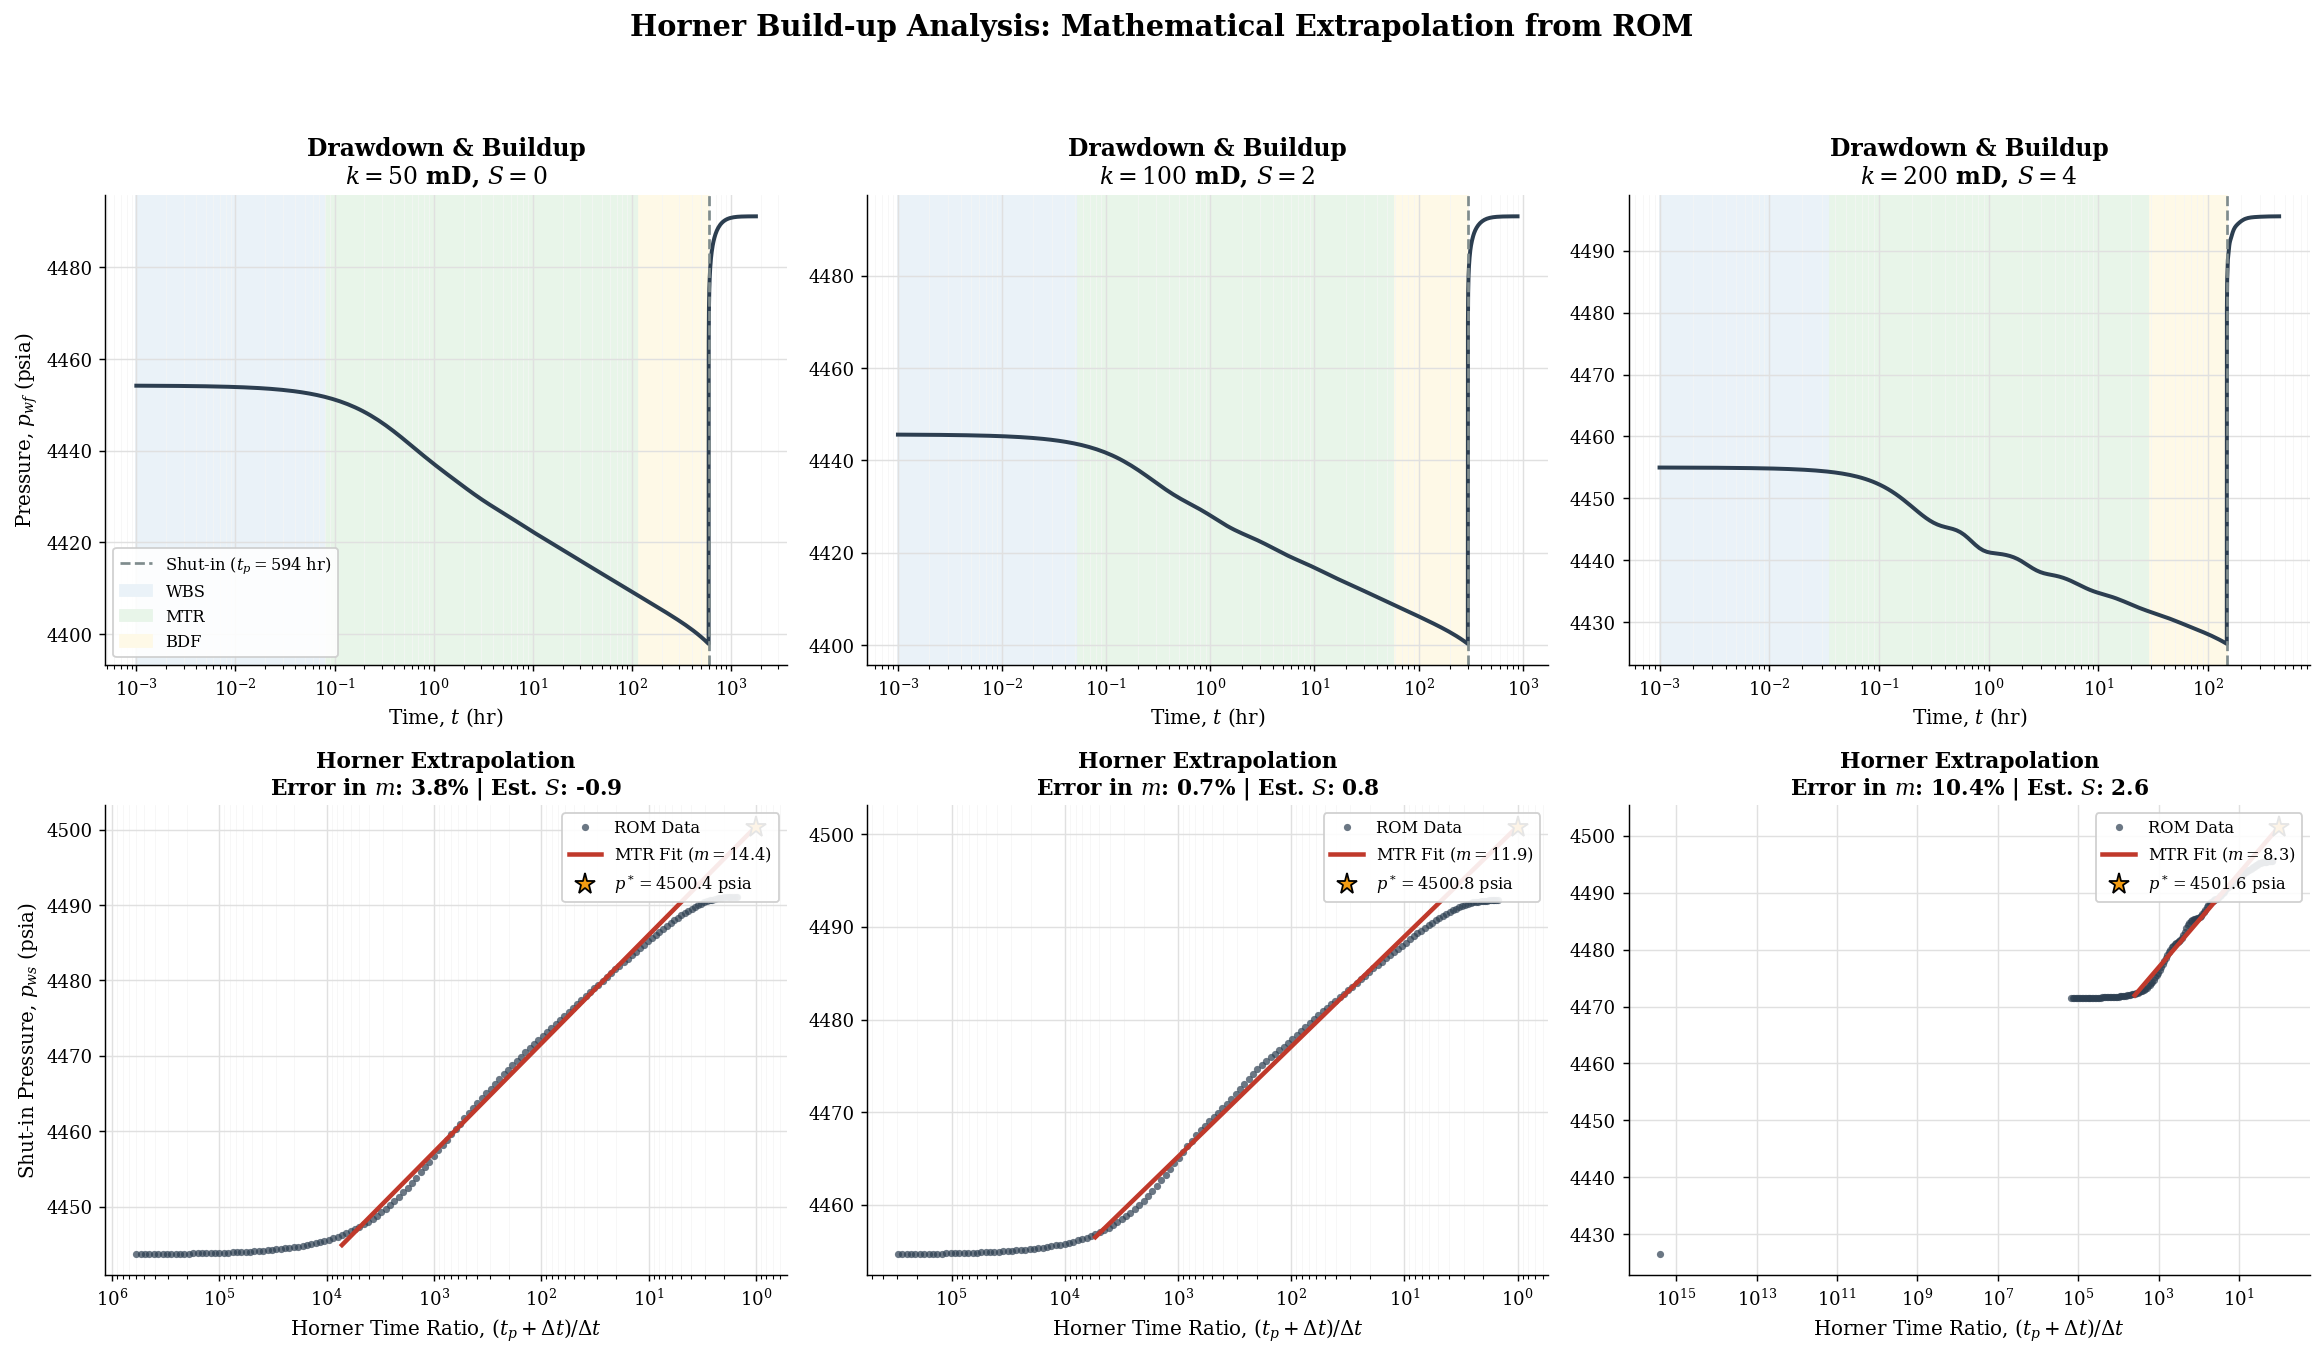

In [63]:
# ── 8.1 Publication-Ready Horner Build-up Analysis ───────────────────────────
buildup_cases = [(50, 0, 500), (100, 2, 800), (200, 4, 1000)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Custom Academic Color Palette
colors = {"wbs": "#EAF2F8", "mtr": "#E8F5E9", "bdf": "#FEF9E7"}
c_line = "#2C3E50"  # Deep slate for data
c_fit  = "#C0392B"  # Rich red for the Horner fit

for col, (k_b, s_b, q_b) in enumerate(buildup_cases):
    tp = min(1000.0, (PHI*MU_CP*CT*RE_FT**2) / (0.000264*k_b) * 0.5)
    res = horner_buildup(k_b, s_b, tp_hr=tp, q_prod=q_b)
    m_an = res["m_H"]

    # ── Top Row: Full Test History ───────────────────────────────────────
    ax_t = axes[0, col]
    ax_t.semilogx(res["t_full"], res["bhp_full"], color=c_line, lw=2.2)
    ax_t.axvline(tp, color="#7F8C8D", ls="--", lw=1.5, label=f"Shut-in ($t_p={tp:.0f}$ hr)")

    # Clean, subtle flow regime shading
    ax_t.axvspan(T_START,      res["t_wbs"], color=colors["wbs"], label="WBS")
    ax_t.axvspan(res["t_wbs"], res["t_pss"], color=colors["mtr"], label="MTR")
    ax_t.axvspan(res["t_pss"], tp,           color=colors["bdf"], label="BDF")

    ax_t.set_xlabel("Time, $t$ (hr)", fontsize=11, fontweight="medium")
    if col == 0: ax_t.set_ylabel("Pressure, $p_{wf}$ (psia)", fontsize=11, fontweight="medium")
    ax_t.set_title(f"Drawdown & Buildup\n$k={k_b}$ mD, $S={s_b}$", fontsize=13, fontweight="bold")
    if col == 0: ax_t.legend(fontsize=9, loc="lower left", framealpha=0.9)

    # ── Bottom Row: Horner Plot ──────────────────────────────────────────
    ax_h = axes[1, col]
    t_H = res["t_H"]
    bhp_H = res["bhp_bu"]

    # Scatter the Horner data (dots instead of lines for physical clarity)
    ax_h.semilogx(t_H, bhp_H, "o", color=c_line, ms=4, alpha=0.7, markeredgecolor='none', label="ROM Data")

    dt_ = res["dt_bu"]
    mtr_h = (dt_ >= res["t_wbs"]) & (dt_ <= res["t_pss"])

    if mtr_h.sum() > 3:
        log_tH_mtr = np.log10(t_H[mtr_h])
        bhp_mtr    = bhp_H[mtr_h]
        coeffs     = np.polyfit(log_tH_mtr, bhp_mtr, 1)
        m_rom      = -coeffs[0]
        
        # Extrapolate p* directly at Horner Time = 1 (where log10(1) = 0)
        p_star_ext = coeffs[1] 

        # Plot the MTR line EXTENDED to t_H = 1
        t_H_fit = np.logspace(0, np.log10(t_H[mtr_h].max()), 100)
        ax_h.semilogx(t_H_fit, np.polyval(coeffs, np.log10(t_H_fit)),
                      color=c_fit, lw=2.5, label=f"MTR Fit ($m={m_rom:.1f}$)")

        # Mark the extrapolated p* point
        ax_h.plot(1.0, p_star_ext, "*", color="#F39C12", ms=12, mec="k", label=f"$p^* = {p_star_ext:.1f}$ psia")

        err_m = abs(m_rom - m_an) / m_an * 100
        ax_h.set_title(f"Horner Extrapolation\nError in $m$: {err_m:.1f}% | Est. $S$: {res['S_est']:.1f}", fontsize=12, fontweight="bold")
    else:
        ax_h.set_title("Horner Plot\n(Insufficient MTR Data)", fontsize=12, fontweight="bold", color="#7F8C8D")

    # Invert x-axis (Horner time decreases to the right)
    ax_h.invert_xaxis()
    ax_h.set_xlabel(r"Horner Time Ratio, $(t_p+\Delta t)/\Delta t$", fontsize=11, fontweight="medium")
    if col == 0: ax_h.set_ylabel("Shut-in Pressure, $p_{ws}$ (psia)", fontsize=11, fontweight="medium")
    ax_h.legend(fontsize=9, framealpha=0.9, loc="upper right")

# ── Global Aesthetics ────────────────────────────────────────────────────────
for ax in axes.flat:
    ax.grid(True, which="major", color="#E0E0E0", linestyle='-', lw=0.8)
    ax.grid(True, which="minor", color="#F5F5F5", linestyle='-', lw=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)

plt.suptitle("Horner Build-up Analysis: Mathematical Extrapolation from ROM", fontsize=16, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig08_horner_buildup_clean.pdf", bbox_inches="tight")
plt.show()

## 9. Deconvolution Module

**Deconvolution** recovers the unit-step response $g(t)$ from a variable-rate pressure record
$\Delta p(t)$ and rate history $q(t)$ by inverting the convolution:

$$\Delta p(t_i) = \sum_{j=0}^{i} \frac{\Delta q_j}{q_{\rm ref}}\,g(t_i - t_j)$$

This is rewritten as a linear system $\mathbf{L}\mathbf{g} = \boldsymbol{\Delta p}$,
where $\mathbf{L}$ is a lower-triangular Toeplitz-like matrix.
Because this problem is ill-posed, **Tikhonov regularisation** (order 2) is applied:

$$\min_{\mathbf{g}\geq 0}\;\|\mathbf{L}\mathbf{g}-\boldsymbol{\Delta p}\|_2^2 + \lambda\|\mathbf{D}_2\mathbf{g}\|_2^2$$

where $\mathbf{D}_2$ is the second-difference matrix (penalises curvature of $g$).

**Application**: Deconvolution can extend the apparent test duration beyond the individual
drawdown periods and reveal features (e.g. boundary effects) hidden in variable-rate data.


Rigorous Deconvolution functions defined.


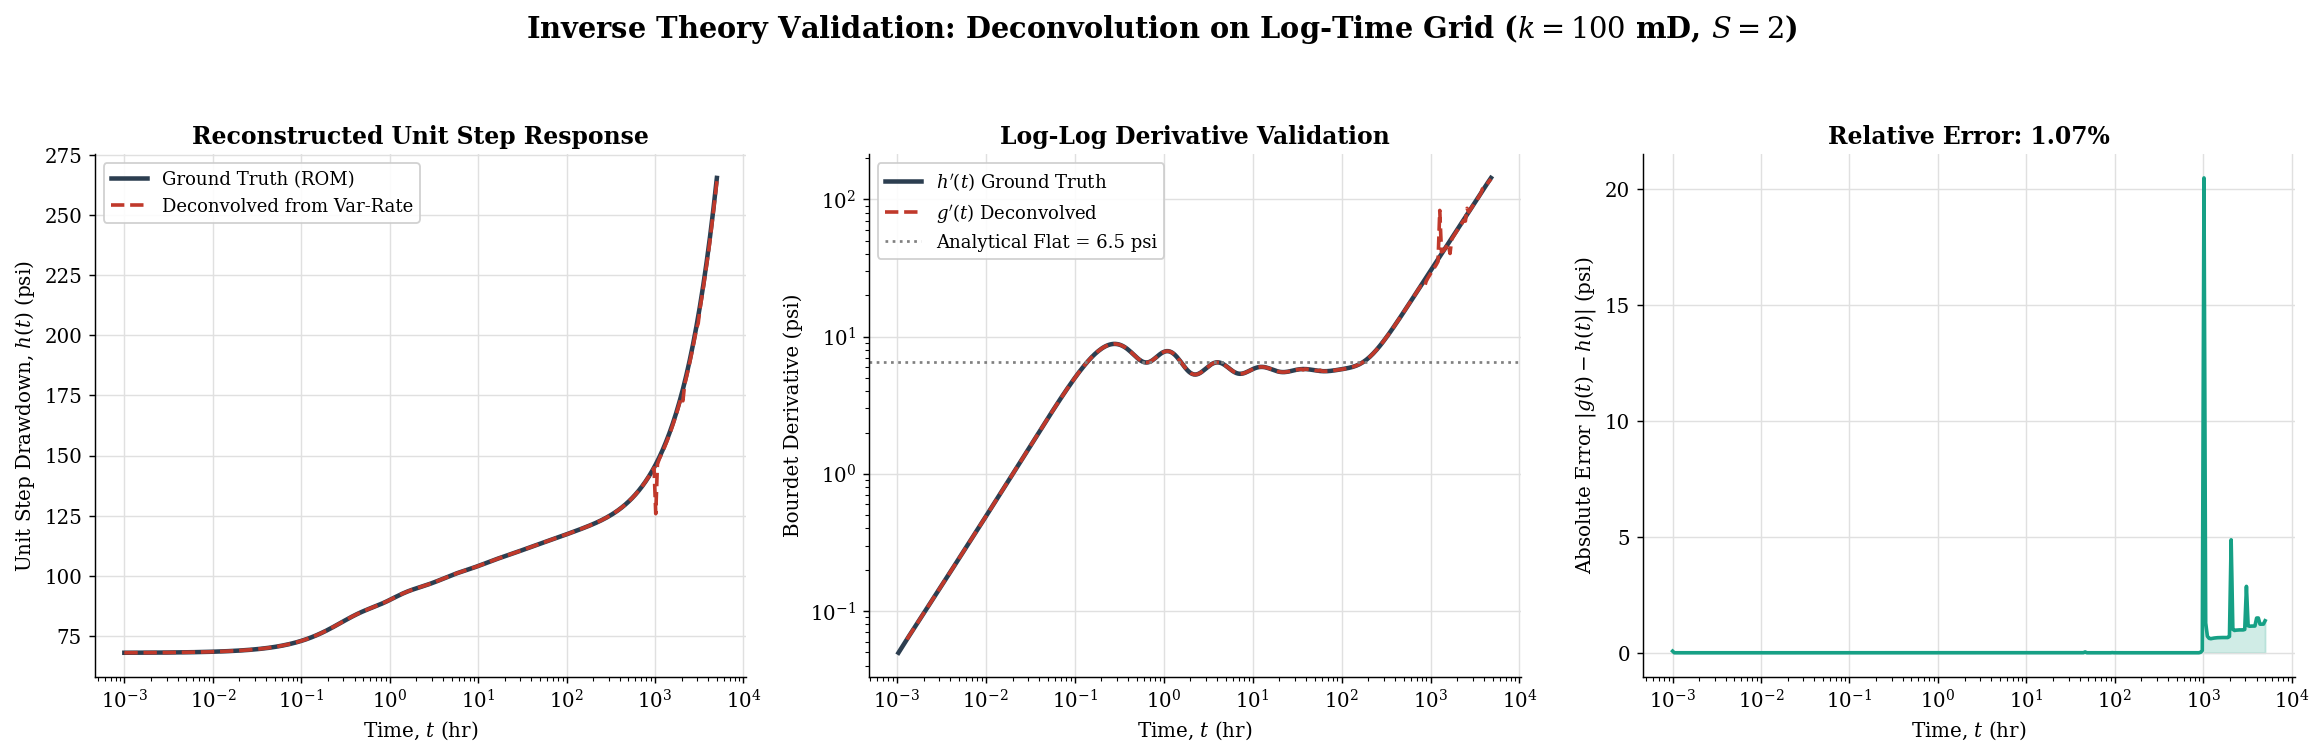

In [64]:
# ── 9.1  Rigorous Log-Grid Deconvolution ──────────────────────────────────────

def build_convolution_matrix(t_hr, q_vec, q_ref):
    """
    Builds the convolution matrix L for an ARBITRARY (e.g., log-spaced) time grid.
    Dynamically interpolates shifted times onto the discrete grid indices.
    L · g ≈ Δp
    """
    N = len(t_hr)
    dq = np.diff(q_vec, prepend=0.0)
    L = np.zeros((N, N))
    
    change_idx = np.where(np.abs(dq) > 1e-4)[0]
    
    for i in range(N):
        for j in change_idx:
            if j > i: 
                continue # Future rate changes cannot affect current time
            
            # Physical shifted time: t_i - t_j
            t_onset = t_hr[j] if j > 0 else 0.0
            t_shift = t_hr[i] - t_onset
            
            if t_shift <= t_hr[0]:
                L[i, 0] += dq[j] / q_ref
                continue
                
            # Find the interpolation interval on the log grid
            k = np.searchsorted(t_hr, t_shift)
            
            if k >= N:
                L[i, N-1] += dq[j] / q_ref
            else:
                # Distribute the rate change via linear interpolation weights
                t_left, t_right = t_hr[k-1], t_hr[k]
                w = (t_shift - t_left) / (t_right - t_left)
                L[i, k-1] += (dq[j] / q_ref) * (1 - w)
                L[i, k]   += (dq[j] / q_ref) * w
                
    return L


def deconvolve(t_hr, dp_psi, q_vec, lam=1e-1, q_ref=500.0, n_iter=3):
    """
    von Schroeter-style regularised deconvolution (Log-Time Smoothing).
    """
    N = len(t_hr)
    L = build_convolution_matrix(t_hr, q_vec, q_ref)

    # Second-difference operator (Penalizes curvature in log-time)
    D2 = np.diff(np.eye(N), n=2, axis=0)

    lam_k = lam
    for _ in range(n_iter):
        # CORRECTED: Tikhonov requires sqrt(lam) in the block matrix
        A_aug = np.vstack([L, np.sqrt(lam_k) * D2])
        b_aug = np.concatenate([dp_psi, np.zeros(N-2)])
        
        g, *_ = np.linalg.lstsq(A_aug, b_aug, rcond=None)
        g = np.maximum(g, 0.0)  # Physical constraint: drawdown must be ≥ 0
        
        # GCV for lambda update
        resid = np.linalg.norm(L @ g - dp_psi)**2
        lam_k = max(lam * resid / (N + 1e-9), 1e-5)

    return g

print("Rigorous Deconvolution functions defined.")


# ── 9.2  Validation: Recovering the Unit Response (Journal Quality Plot) ─────

k_dc, s_dc = 100, 2
sid_dc = VARIABLE_SCHEDS[0] if VARIABLE_SCHEDS else 2

# 1. Load Data & Generate ROM "Truth"
cd_dc = next((base / f"k{k_dc:03d}_s{s_dc:02d}_sched{sid_dc}" for base in [VAL_DIR, TRAINING_DIR] 
               if (base / f"k{k_dc:03d}_s{s_dc:02d}_sched{sid_dc}"/"well_data.mat").exists()), None)

bhp_m_dc, t_dc, q_dc, _, pm_dc = load_well_data(cd_dc)
bhp_r_dc, _, _ = query_rom(k_dc, s_dc, t_dc, q_dc)
dp_dc = np.clip(P_INIT - bhp_r_dc, 1e-2, None) # Positive drawdown

# 2. Reference Unit Step Response (Ground Truth)
q_ref_dc = max(float(np.atleast_1d(pm_dc["rates_STBd"])[0]), 300.0)
h_ref_raw, _ = unit_step_response(k_dc, s_dc, t_dc, q_ref=q_ref_dc)
h_true = np.abs(h_ref_raw) # Align signs (Drawdown is positive)

# 3. Execute Deconvolution
g_dc = deconvolve(t_dc, dp_dc, q_dc, lam=1e-1, q_ref=q_ref_dc)

# Error Calculation
e_dc = np.linalg.norm(g_dc - h_true) / (np.linalg.norm(h_true) + 1e-9)

# 4. Publication-Ready Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
c_true = "#2C3E50"  # Dark Slate
c_pred = "#C0392B"  # Rich Red

# Panel A: Unit Step Reconstruction
axes[0].semilogx(t_dc, h_true, color=c_true, lw=2.5, label="Ground Truth (ROM)")
axes[0].semilogx(t_dc, g_dc, color=c_pred, lw=2.0, ls="--", label="Deconvolved from Var-Rate")
axes[0].set_xlabel("Time, $t$ (hr)", fontsize=11)
axes[0].set_ylabel("Unit Step Drawdown, $h(t)$ (psi)", fontsize=11)
axes[0].set_title(f"Reconstructed Unit Step Response", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10, framealpha=0.9)

# Panel B: Bourdet Derivative Diagnostic
dp_g = np.clip(g_dc, 1e-2, None)
dp_h = np.clip(h_true, 1e-2, None)
tg, _, dg = bourdet(t_dc, dp_g)
th, _, dh = bourdet(t_dc, dp_h)

axes[1].loglog(th, dh, color=c_true, lw=2.5, label="$h'(t)$ Ground Truth")
axes[1].loglog(tg, dg, color=c_pred, lw=2.0, ls="--", label="$g'(t)$ Deconvolved")

kh_dc = k_dc * H_FT
dp_prim = 70.6 * q_ref_dc * MU_CP * BO / kh_dc
axes[1].axhline(dp_prim, color="gray", ls=":", lw=1.5, label=f"Analytical Flat = {dp_prim:.1f} psi")

axes[1].set_xlabel("Time, $t$ (hr)", fontsize=11)
axes[1].set_ylabel(r"Bourdet Derivative (psi)", fontsize=11)
axes[1].set_title("Log-Log Derivative Validation", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10, framealpha=0.9)

# Panel C: Absolute Reconstruction Error
err_abs = np.abs(g_dc - h_true)
axes[2].semilogx(t_dc, err_abs, color="#16A085", lw=2.0)
axes[2].fill_between(t_dc, 0, err_abs, color="#16A085", alpha=0.2)
axes[2].set_xlabel("Time, $t$ (hr)", fontsize=11)
axes[2].set_ylabel(r"Absolute Error $|g(t) - h(t)|$ (psi)", fontsize=11)
axes[2].set_title(f"Relative Error: {e_dc:.2%}", fontsize=13, fontweight="bold")

# Global Formatting
for ax in axes:
    ax.grid(True, which="major", color="#E0E0E0", linestyle='-', lw=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(f"Inverse Theory Validation: Deconvolution on Log-Time Grid ($k={k_dc}$ mD, $S={s_dc}$)", 
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig09_deconvolution_clean.pdf", bbox_inches="tight")
plt.show()

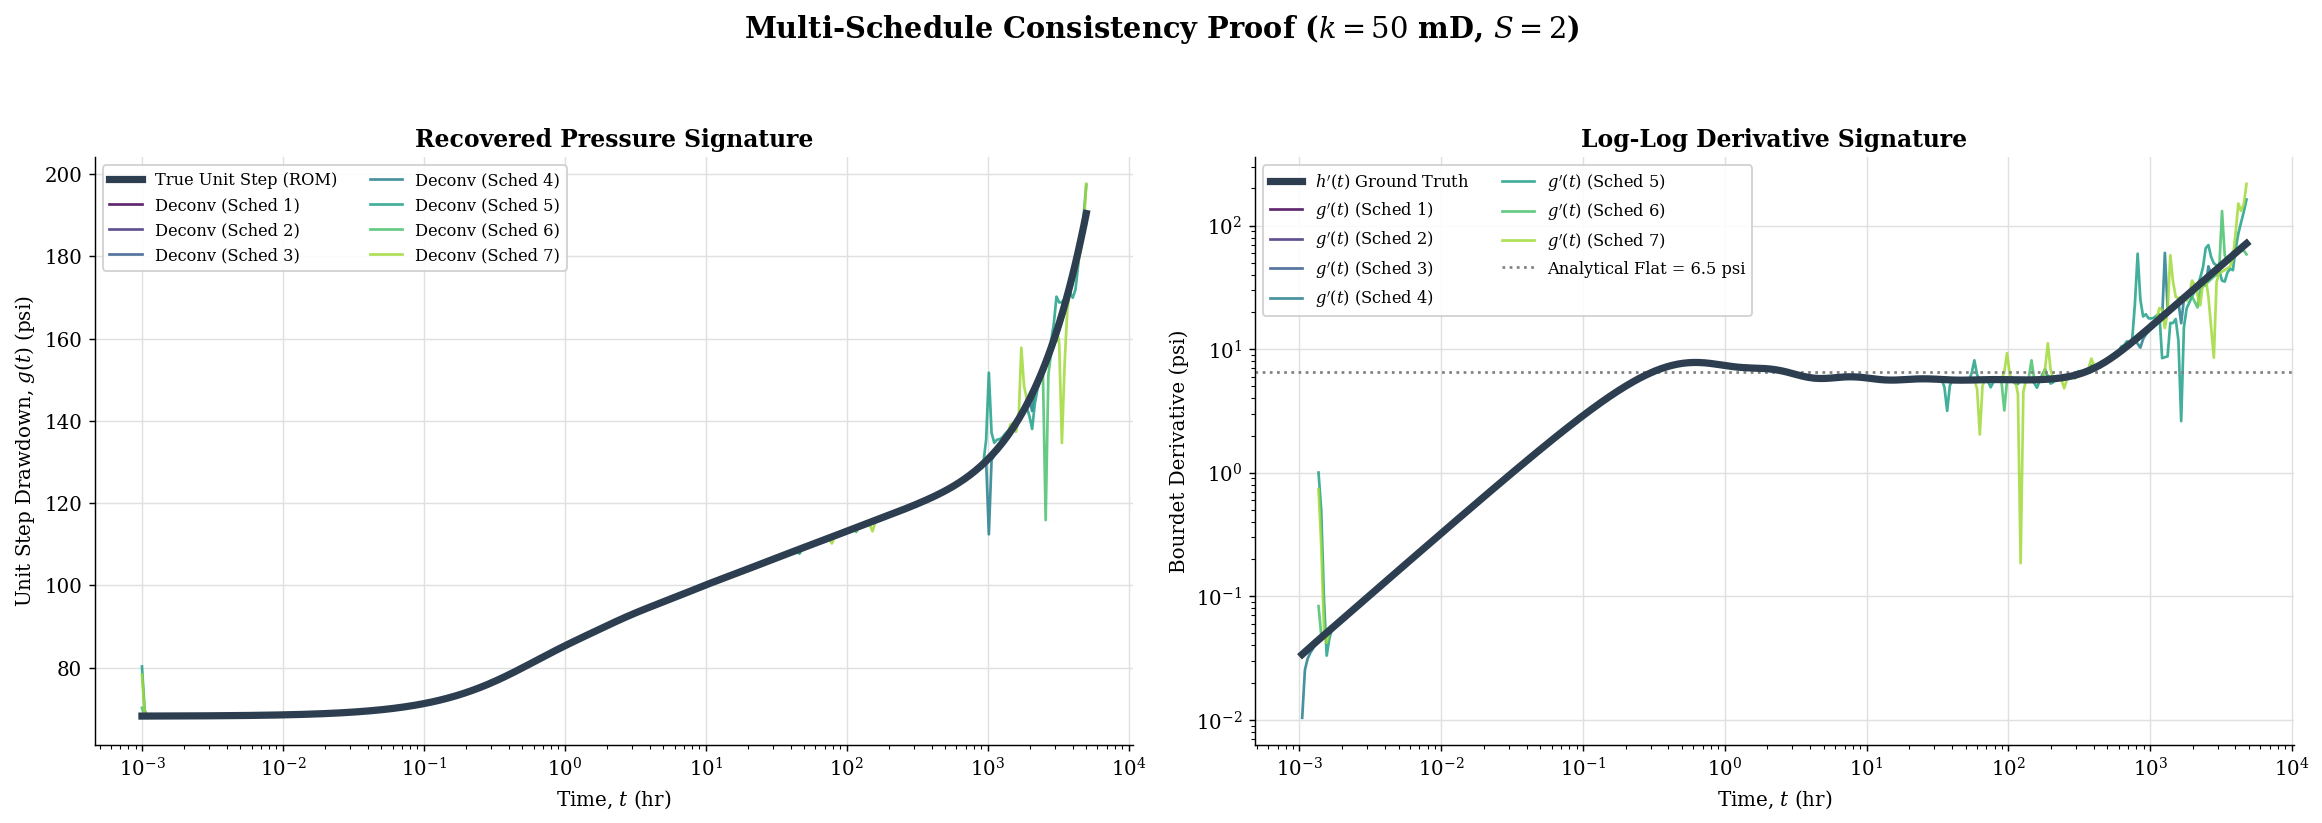

In [65]:
# ── 9.2  Multi-Schedule Deconvolution: Proof of Consistency ───────────────
# Deconvolution from multiple independent rate histories should collapse
# into the EXACT same underlying signature g(t).

k_mc, s_mc  = 50, 2
q_ref_mc    = 500.0

# 1. Generate the Ground Truth Unit Step Response from ROM
t_ref_mc     = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)
h_ref_raw, _ = unit_step_response(k_mc, s_mc, t_ref_mc, q_ref=q_ref_mc)
h_true       = np.abs(h_ref_raw) # Ensure positive drawdown

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
c_true = "#2C3E50" # Deep Slate for Ground Truth

# Panel A: Ground Truth h(t)
axes[0].semilogx(t_ref_mc, h_true, color=c_true, lw=4.0, label="True Unit Step (ROM)", zorder=10)

# Panel B: Ground Truth Derivative h'(t)
dp_h = np.clip(h_true, 1e-2, None)
th, _, dh = bourdet(t_ref_mc, dp_h)
axes[1].loglog(th, dh, color=c_true, lw=4.0, label="$h'(t)$ Ground Truth", zorder=10)

# 2. Iterate through ALL schedules and deconvolve each independently
cmap_mc = plt.cm.viridis # Scientific colormap for differentiating schedules
valid_count = 0

for sid in SCHEDS:
    # Safely locate the data file
    cd_mc = next((base / f"k{k_mc:03d}_s{s_mc:02d}_sched{sid}" for base in [VAL_DIR, TRAINING_DIR] 
                  if (base / f"k{k_mc:03d}_s{s_mc:02d}_sched{sid}"/"well_data.mat").exists()), None)
    
    if cd_mc is None: continue
    
    try:
        # Load and simulate
        _, t_j, q_j, _, _ = load_well_data(cd_mc)
        bhp_j, _, _ = query_rom(k_mc, s_mc, t_j, q_j)
        dp_j = np.clip(P_INIT - bhp_j, 1e-2, None)
        
        # Deconvolve using the newly corrected function (lam=1e-1)
        g_j  = deconvolve(t_j, dp_j, q_j, lam=1e-1, q_ref=q_ref_mc)
        
        # Color format
        col = cmap_mc(valid_count / len(SCHEDS))
        valid_count += 1
        
        # Panel A: Plot recovered g(t) exactly on its native grid
        axes[0].semilogx(t_j, g_j, color=col, lw=1.5, alpha=0.85, 
                         label=f"Deconv (Sched {sid})")
        
        # Panel B: Plot recovered derivative g'(t)
        dp_g = np.clip(g_j, 1e-2, None)
        tg, _, dg = bourdet(t_j, dp_g)
        axes[1].loglog(tg, dg, color=col, lw=1.5, alpha=0.85, 
                       label=f"$g'(t)$ (Sched {sid})")
                       
    except Exception as e:
        print(f"⚠️ Error on Sched {sid}: {e}")

# 3. Aesthetics: Panel A (Pressure Signature)
axes[0].set_xlabel("Time, $t$ (hr)", fontsize=11, fontweight="medium")
axes[0].set_ylabel("Unit Step Drawdown, $g(t)$ (psi)", fontsize=11, fontweight="medium")
axes[0].set_title("Recovered Pressure Signature", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9, loc="upper left", framealpha=0.9, ncol=2)

# 4. Aesthetics: Panel B (Log-Log Derivative Signature)
kh_mc   = k_mc * H_FT
dp_prim = 70.6 * q_ref_mc * MU_CP * BO / kh_mc
axes[1].axhline(dp_prim, color="gray", ls=":", lw=1.5, label=f"Analytical Flat = {dp_prim:.1f} psi")

axes[1].set_xlabel("Time, $t$ (hr)", fontsize=11, fontweight="medium")
axes[1].set_ylabel("Bourdet Derivative (psi)", fontsize=11, fontweight="medium")
axes[1].set_title("Log-Log Derivative Signature", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="best", framealpha=0.9, ncol=2)

# 5. Global Formatting
for ax in axes:
    ax.grid(True, which="major", color="#E0E0E0", linestyle='-', lw=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(f"Multi-Schedule Consistency Proof ($k={k_mc}$ mD, $S={s_mc}$)", 
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig10_multischedule_deconv_clean.pdf", bbox_inches="tight")
plt.show()

## 10. Parametric + Variable-Rate Prediction Studies

The ROM is used here as a **fast parametric simulator** for scenario studies
that would each require a full MRST run.  All predictions use the Backward-Euler
ROM integrator with interpolated operators.


In [52]:
T_PRED = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)

def schedule_qvec(sched_steps, t_hr):
    """
    sched_steps: list of (t_start_hr, rate_STBd)
    Returns q(t) vector aligned with t_hr.
    """
    q = np.full(len(t_hr), float(sched_steps[0][1]))
    for tc, rv in sched_steps[1:]:
        q[t_hr >= tc] = float(rv)
    return q

def predict(k_star, s_star, rate_sched):
    assert 10 <= k_star <= 300, f"k={k_star} outside [10,300]"
    assert  0 <= s_star <=   8, f"S={s_star} outside [0,8]"
    q    = schedule_qvec(rate_sched, T_PRED)
    t0   = time.perf_counter()
    bhp_r, pf_r, _ = query_rom(k_star, s_star, T_PRED, q)
    dp_r = np.clip(P_INIT - bhp_r, 0, None)
    te_r, _ = material_balance_time(T_PRED, q)
    rnp_r   = rate_normalized_pressure(dp_r, q)
    return dict(t_hr=T_PRED, bhp_psia=bhp_r, dp_psi=dp_r,
                p_field=pf_r, q_vec=q, te=te_r, rnp=rnp_r,
                wall_ms=(time.perf_counter()-t0)*1000)

print("predict() ready.  ROM valid range: k ∈ [10,300] mD,  S ∈ [0,8]")


predict() ready.  ROM valid range: k ∈ [10,300] mD,  S ∈ [0,8]


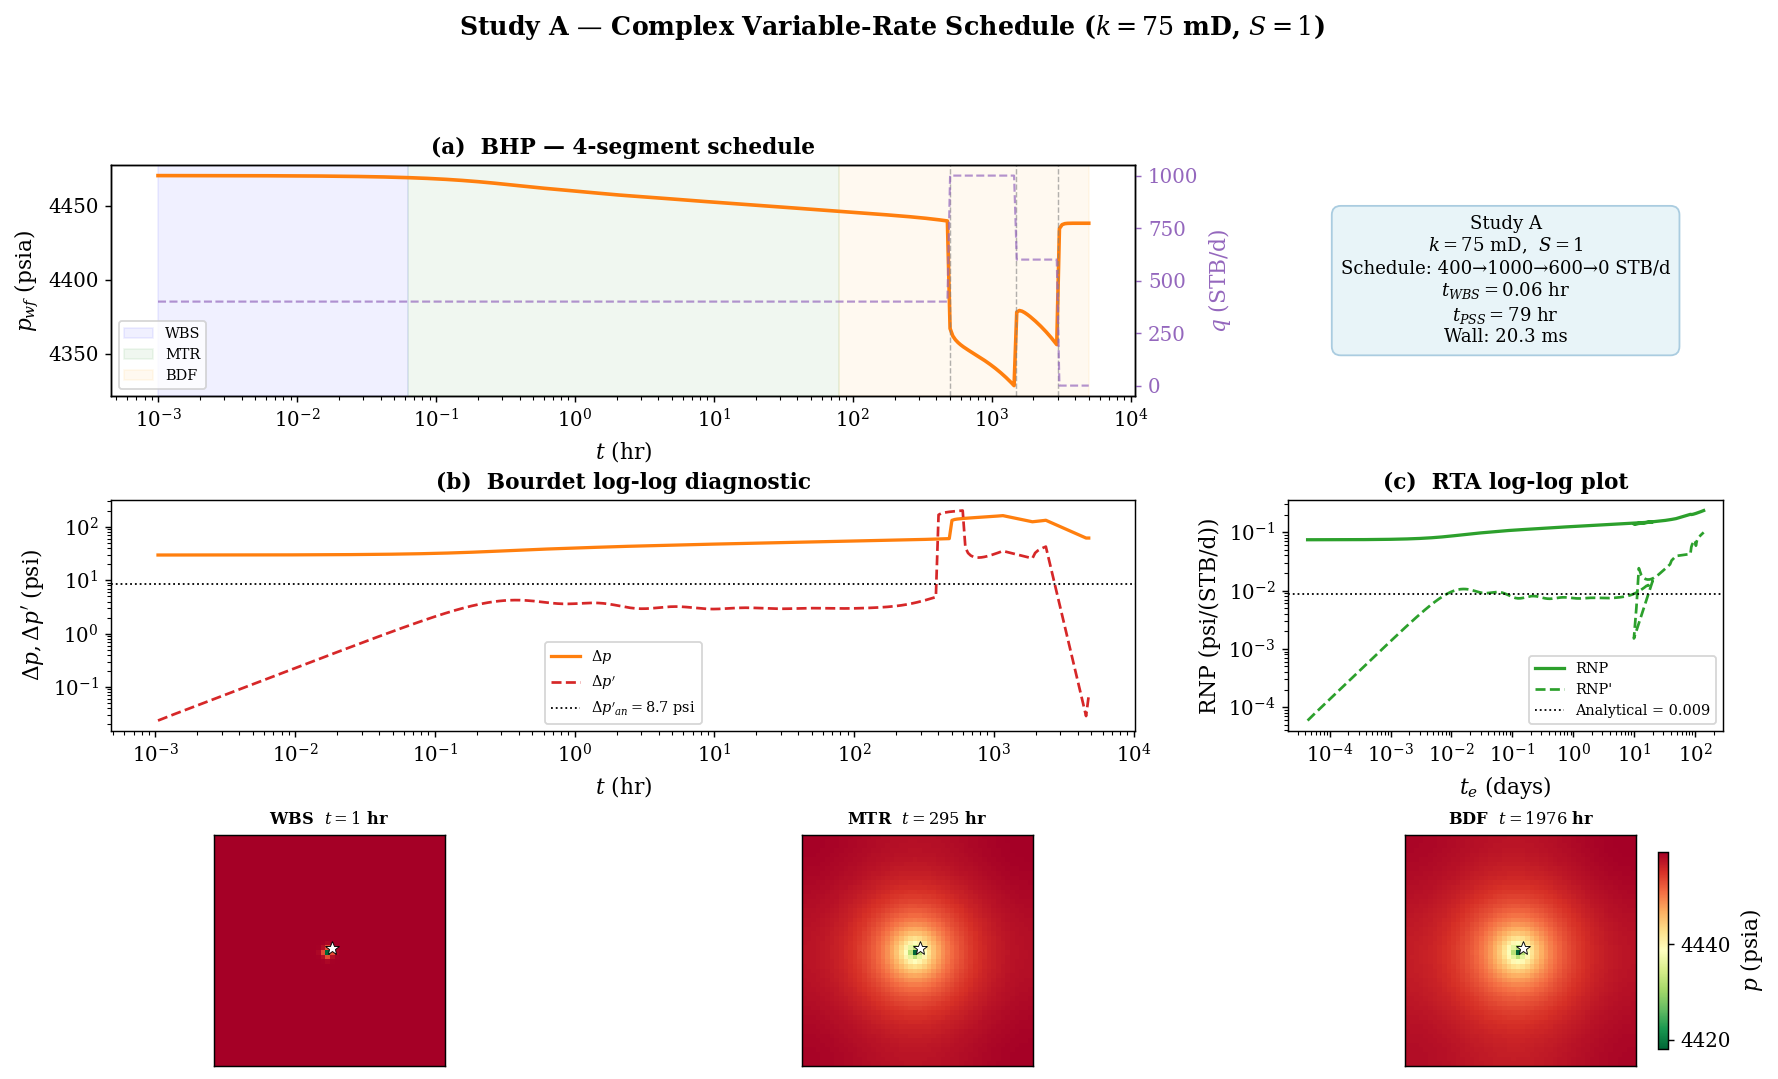

Prediction executed successfully in: 20.3 ms


In [67]:

# ── Study A: Complex multi-segment schedule ─────────────────────────────
# Ramp-up → plateau → step-down → pressure build-up
sched_A = [(0, 400), (500, 1000), (1500, 600), (3000, 0)]
k_A, s_A = 75, 1

# Execute prediction
rA = predict(k_A, s_A, sched_A)

# Theoretical milestones
t_wbs_A  = 170000.0 * C_WBS * MU_CP * np.exp(0.14*s_A) / (k_A*H_FT)
t_pss_A  = (PHI*MU_CP*CT*RE_FT**2)/(0.000264*k_A)*0.1
dp_an_A  = 70.6 * 1000 * MU_CP * BO / (k_A*H_FT)   # peak rate period

# RNP analysis
tv_A, rv_A, dv_A = rnp_derivative(rA["te"], rA["rnp"])

# ── Figure Setup ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel A: BHP ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.semilogx(rA["t_hr"], rA["bhp_psia"], color="C1", lw=2)
for tc, _ in sched_A[1:]:
    ax1.axvline(tc, color="gray", ls="--", lw=0.8, alpha=0.6)

# Flow regime shading
ax1.axvspan(T_START, t_wbs_A, alpha=0.06, color="blue", label="WBS")
ax1.axvspan(t_wbs_A, t_pss_A, alpha=0.06, color="green", label="MTR")
ax1.axvspan(t_pss_A, T_END,   alpha=0.06, color="orange", label="BDF")
ax1.set_xlabel("$t$ (hr)")
ax1.set_ylabel("$p_{wf}$ (psia)")
ax1.set_title("(a)  BHP — 4-segment schedule")
ax1.legend(fontsize=8)

# Rate overlay on twin axis
ax1b = ax1.twinx()
ax1b.semilogx(rA["t_hr"], rA["q_vec"], color="C4", lw=1.2, ls="--", alpha=0.7)
ax1b.set_ylabel("$q$ (STB/d)", color="C4")
ax1b.tick_params(colors="C4")

# --- Panel B: Info Text Box ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")
kh_A = k_A * H_FT
ax2.text(0.5, 0.5,
    f"Study A\n$k={k_A}$ mD,  $S={s_A}$\n"
    f"Schedule: 400→1000→600→0 STB/d\n"
    f"$t_{{WBS}}={t_wbs_A:.2f}$ hr\n"
    f"$t_{{PSS}}={t_pss_A:.0f}$ hr\n"
    f"Wall: {rA['wall_ms']:.1f} ms",
    ha="center", va="center", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8f4f8", ec="#aacce0"))

# --- Panel C: Bourdet log-log diagnostic ---
ax3 = fig.add_subplot(gs[1, :2])
dp_A = np.clip(rA["dp_psi"], 1e-2, None)
t_t, dp_t, dd_t = bourdet(rA["t_hr"], dp_A)

if len(dd_t) > 2:
    ax3.loglog(t_t, dp_t, color="C1", lw=1.8, label=r"$\Delta p$")
    ax3.loglog(t_t, dd_t, color="C3", lw=1.5, ls="--", label=r"$\Delta p'$")

ax3.axhline(dp_an_A, color="k", ls=":", lw=1, label=f"$\Delta p'_{{an}}={dp_an_A:.1f}$ psi")
ax3.set_xlabel("$t$ (hr)")
ax3.set_ylabel(r"$\Delta p, \Delta p'$ (psi)")
ax3.set_title("(b)  Bourdet log-log diagnostic")
ax3.legend(fontsize=8)

# --- Panel D: RTA log-log plot ---
ax4 = fig.add_subplot(gs[1, 2])
if len(dv_A) > 2:
    ax4.loglog(tv_A, rv_A, color="C2", lw=1.8, label="RNP")
    ax4.loglog(tv_A, dv_A, color="C2", lw=1.5, ls="--", label="RNP'")

rnp_an = dp_an_A / 1000.0  # Analytical level based on peak rate
ax4.axhline(rnp_an, color="k", ls=":", lw=1, label=f"Analytical = {rnp_an:.3f}")
ax4.set_xlabel("$t_e$ (days)")
ax4.set_ylabel("RNP (psi/(STB/d))")
ax4.set_title("(c)  RTA log-log plot")
ax4.legend(fontsize=8)

# --- Panel E: Pressure Snapshots ---
snaps = [("WBS", 0.5), ("MTR", 300.0), ("BDF", 2000.0)]
for col_s, (lbl_s, t_tg) in enumerate(snaps):
    idx_s = np.argmin(np.abs(rA["t_hr"] - t_tg))
    ax_s  = fig.add_subplot(gs[2, col_s])
    
    # Reshape and plot the 2D pressure field
    p_2d = rA["p_field"][:, idx_s].reshape(NY, NX)
    im_s = ax_s.imshow(p_2d, origin="lower", cmap="RdYlGn_r", aspect="equal")
    
    # Mark the well location (assuming well is in the center)
    ax_s.plot(NX//2, NY//2, "w*", ms=8, mec="k", mew=0.5, zorder=5)
    ax_s.set_title(f"{lbl_s}  $t={rA['t_hr'][idx_s]:.0f}$ hr", fontsize=9)
    ax_s.set_xticks([])
    ax_s.set_yticks([])
    
    if col_s == 2: 
        plt.colorbar(im_s, ax=ax_s, shrink=0.85, label="$p$ (psia)")

# ── Final Output ────────────────────────────────────────────────────────
fig.suptitle(f"Study A — Complex Variable-Rate Schedule ($k={k_A}$ mD, $S={s_A}$)",
             fontsize=14, fontweight="bold", y=1.01)

plt.savefig(FIG_DIR/"fig11_studyA_complex.pdf", bbox_inches="tight")
plt.show()

print(f"Prediction executed successfully in: {rA['wall_ms']:.1f} ms")

Study B: 6 ROM queries in 76 ms total
Study B: mean 1/k error = 10.5%


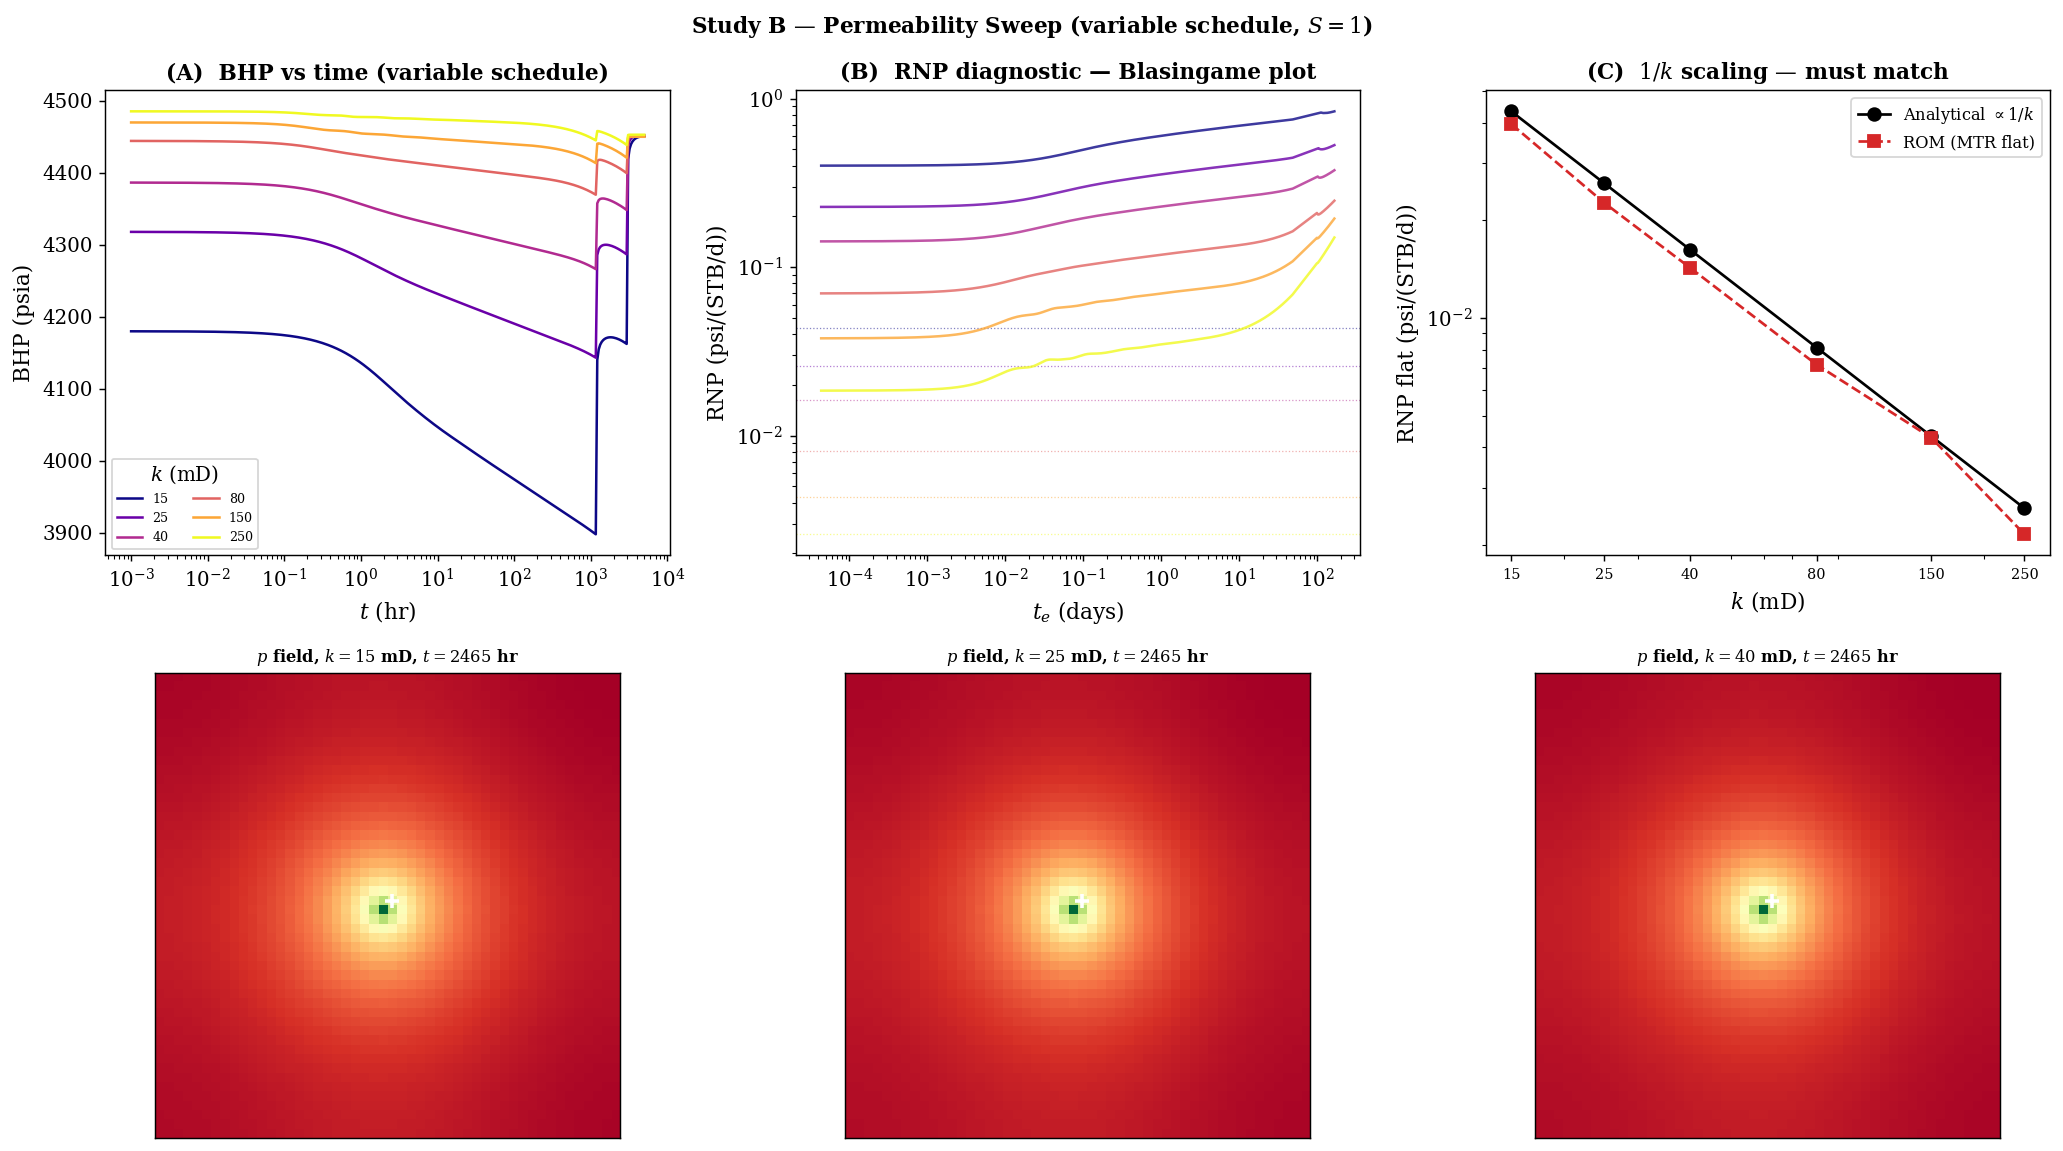

In [68]:
# ── Study B: Permeability sweep — multi-rate schedule ───────────────────
# Same variable schedule applied to 6 different permeabilities
sched_B = [(0, 800), (1200, 400), (3000, 0)]
S_B     = 1
k_sweep = [15, 25, 40, 80, 150, 250]
cmap_B  = plt.cm.plasma
cols_B  = [cmap_B(i/(len(k_sweep)-1)) for i in range(len(k_sweep))]

res_B = {k: predict(k, S_B, sched_B) for k in k_sweep}
print(f"Study B: {len(k_sweep)} ROM queries in "
      f"{sum(r['wall_ms'] for r in res_B.values()):.0f} ms total")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for k_v, col in zip(k_sweep, cols_B):
    r = res_B[k_v]
    axes[0,0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=1.4,
                       label=f"{k_v}")
axes[0,0].set_xlabel("$t$ (hr)"); axes[0,0].set_ylabel("BHP (psia)")
axes[0,0].set_title("(A)  BHP vs time (variable schedule)")
axes[0,0].legend(title="$k$ (mD)", fontsize=7, ncol=2)

flat_sim_B, flat_an_B = [], []
for k_v, col in zip(k_sweep, cols_B):
    r  = res_B[k_v]
    tv, rv, dv = rnp_derivative(r["te"], r["rnp"])
    if len(dv) > 2: axes[0,1].loglog(tv, rv, color=col, lw=1.4, alpha=0.8)
    kh_v   = k_v * H_FT
    rnp_an = 70.6 * 800 * MU_CP * BO / (kh_v * 800)
    axes[0,1].axhline(rnp_an, color=col, ls=":", lw=0.7, alpha=0.5)
    _, t_wbs_v, t_pss_v, *_ = physics_screen(k_v, S_B)
    te_mtr = (tv >= t_wbs_v/24) & (tv <= t_pss_v/24)
    flat_sim_B.append(float(np.median(dv[te_mtr])) if te_mtr.sum()>3 else np.nan)
    flat_an_B.append(rnp_an)
axes[0,1].set_xlabel("$t_e$ (days)"); axes[0,1].set_ylabel("RNP (psi/(STB/d))")
axes[0,1].set_title("(B)  RNP diagnostic — Blasingame plot")

# 1/k scaling
axes[0,2].loglog(k_sweep, flat_an_B, "k-o", ms=7, lw=1.5,
                 label=r"Analytical $\propto 1/k$")
axes[0,2].loglog(k_sweep, flat_sim_B, "s--", color="C3", ms=7, lw=1.5,
                 label="ROM (MTR flat)")
axes[0,2].set_xlabel("$k$ (mD)"); axes[0,2].set_ylabel("RNP flat (psi/(STB/d))")
axes[0,2].set_title(r"(C)  $1/k$ scaling — must match"); axes[0,2].legend(fontsize=9)
axes[0,2].set_xticks(k_sweep); axes[0,2].set_xticklabels(k_sweep, fontsize=8)

# Pressure snapshot at BDF
t_snap = 2500.0
for k_v, col in zip(k_sweep[:3], cols_B[:3]):
    r   = res_B[k_v]
    idx = np.argmin(np.abs(r["t_hr"]-t_snap))
    axes[1, k_sweep[:3].index(k_v)].imshow(
        r["p_field"][:, idx].reshape(NY,NX),
        origin="lower", cmap="RdYlGn_r", aspect="equal")
    axes[1, k_sweep[:3].index(k_v)].set_title(
        f"$p$ field, $k={k_v}$ mD, $t={r['t_hr'][idx]:.0f}$ hr", fontsize=9)
    axes[1, k_sweep[:3].index(k_v)].plot(NX//2,NY//2,"w+",ms=8,mew=2)
    axes[1, k_sweep[:3].index(k_v)].set_xticks([]); axes[1, k_sweep[:3].index(k_v)].set_yticks([])

rel_err_B = [abs(s-a)/a*100 if not np.isnan(s) else np.nan
             for s,a in zip(flat_sim_B,flat_an_B)]
print(f"Study B: mean 1/k error = {np.nanmean(rel_err_B):.1f}%")
fig.suptitle(f"Study B — Permeability Sweep (variable schedule, $S={S_B}$)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig12_studyB_k_sweep.pdf", bbox_inches="tight")
plt.show()


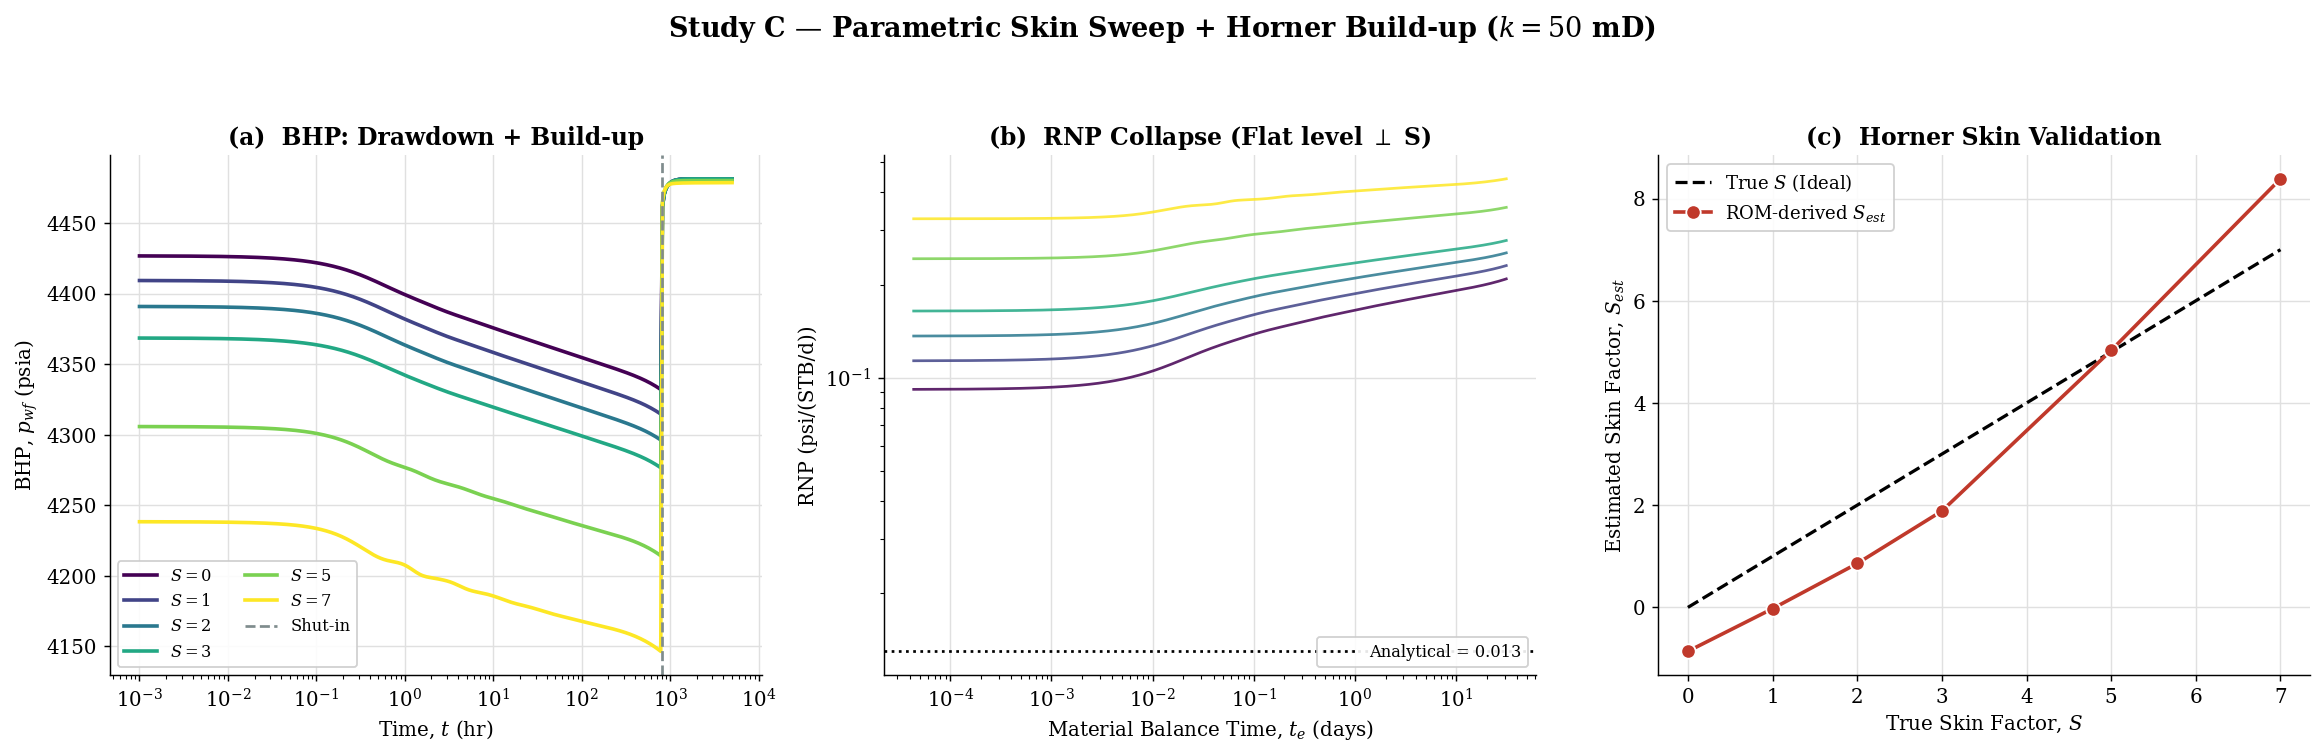

In [71]:
# ── Study C: Skin Sweep — Build-up after Drawdown ─────────────────────────
S_sweep_C = [0, 1, 2, 3, 5, 7]
k_C       = 50
sched_C   = [(0, 800), (800, 0)]   # 800 hr drawdown, then shut-in

# Setup Scientific Colormap
cmap_C = plt.cm.viridis
cols_C = [cmap_C(i / (len(S_sweep_C) - 1)) for i in range(len(S_sweep_C))]

# 1. Run Drawdown Predictions
res_C = {s: predict(k_C, s, sched_C) for s in S_sweep_C}

# 2. Figure Setup
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel A: BHP ---
for s_v, col in zip(S_sweep_C, cols_C):
    r = res_C[s_v]
    axes[0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=2.0, label=f"$S={s_v}$")

axes[0].axvline(800, color="#7F8C8D", ls="--", lw=1.5, label="Shut-in")
axes[0].set_xlabel("Time, $t$ (hr)", fontsize=11)
axes[0].set_ylabel("BHP, $p_{wf}$ (psia)", fontsize=11)
axes[0].set_title("(a)  BHP: Drawdown + Build-up", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9, ncol=2, loc="lower left", framealpha=0.9)

# --- Panel B: RNP Collapse ---
dp_an_C  = 70.6 * 800 * MU_CP * BO / (k_C * H_FT)
rnp_an_C = dp_an_C / 800.0

for s_v, col in zip(S_sweep_C, cols_C):
    r = res_C[s_v]
    tv, rv, dv = rnp_derivative(r["te"], r["rnp"])
    if len(dv) > 2:
        axes[1].loglog(tv, rv, color=col, lw=1.5, alpha=0.85)

axes[1].axhline(rnp_an_C, color="k", ls=":", lw=1.5, label=f"Analytical = {rnp_an_C:.3f}")
axes[1].set_xlabel("Material Balance Time, $t_e$ (days)", fontsize=11)
axes[1].set_ylabel("RNP (psi/(STB/d))", fontsize=11)
# Note: Using raw string r"..." to prevent LaTeX \perp from crashing
axes[1].set_title(r"(b)  RNP Collapse (Flat level $\perp$ S)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="lower right", framealpha=0.9)

# --- Panel C: Horner Skin Estimate ---
S_est_C = []
for s_v in S_sweep_C:
    # BUG FIX: horner_buildup returns a dict directly, no unpacking needed.
    bu_dict = horner_buildup(k_C, s_v, tp_hr=800, q_prod=800, n_prod=120, n_build=120)
    S_est_C.append(bu_dict["S_est"])

axes[2].plot(S_sweep_C, S_sweep_C, "k--", lw=1.8, label="True $S$ (Ideal)")
axes[2].plot(S_sweep_C, S_est_C, "o-", color="#C0392B", ms=8, lw=2.0, markeredgecolor='white',
             label=r"ROM-derived $S_{est}$")

axes[2].set_xlabel("True Skin Factor, $S$", fontsize=11)
axes[2].set_ylabel("Estimated Skin Factor, $S_{est}$", fontsize=11)
axes[2].set_title("(c)  Horner Skin Validation", fontsize=13, fontweight="bold")
axes[2].legend(fontsize=10, framealpha=0.9)

# ── Global Formatting ───────────────────────────────────────────────────
for ax in axes:
    ax.grid(True, which="major", color="#E0E0E0", linestyle='-', lw=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f"Study C — Parametric Skin Sweep + Horner Build-up ($k={k_C}$ mD)",
             fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig13_studyC_skin_clean.pdf", bbox_inches="tight")
plt.show()

Final cumulative production [STB]:
  Constant 800                  166667
  Ramp-up                       154542
  Ramp-down                      95458
  Step-down+BU                   71660
  Pulse                          66176
  Build-up step                  65881


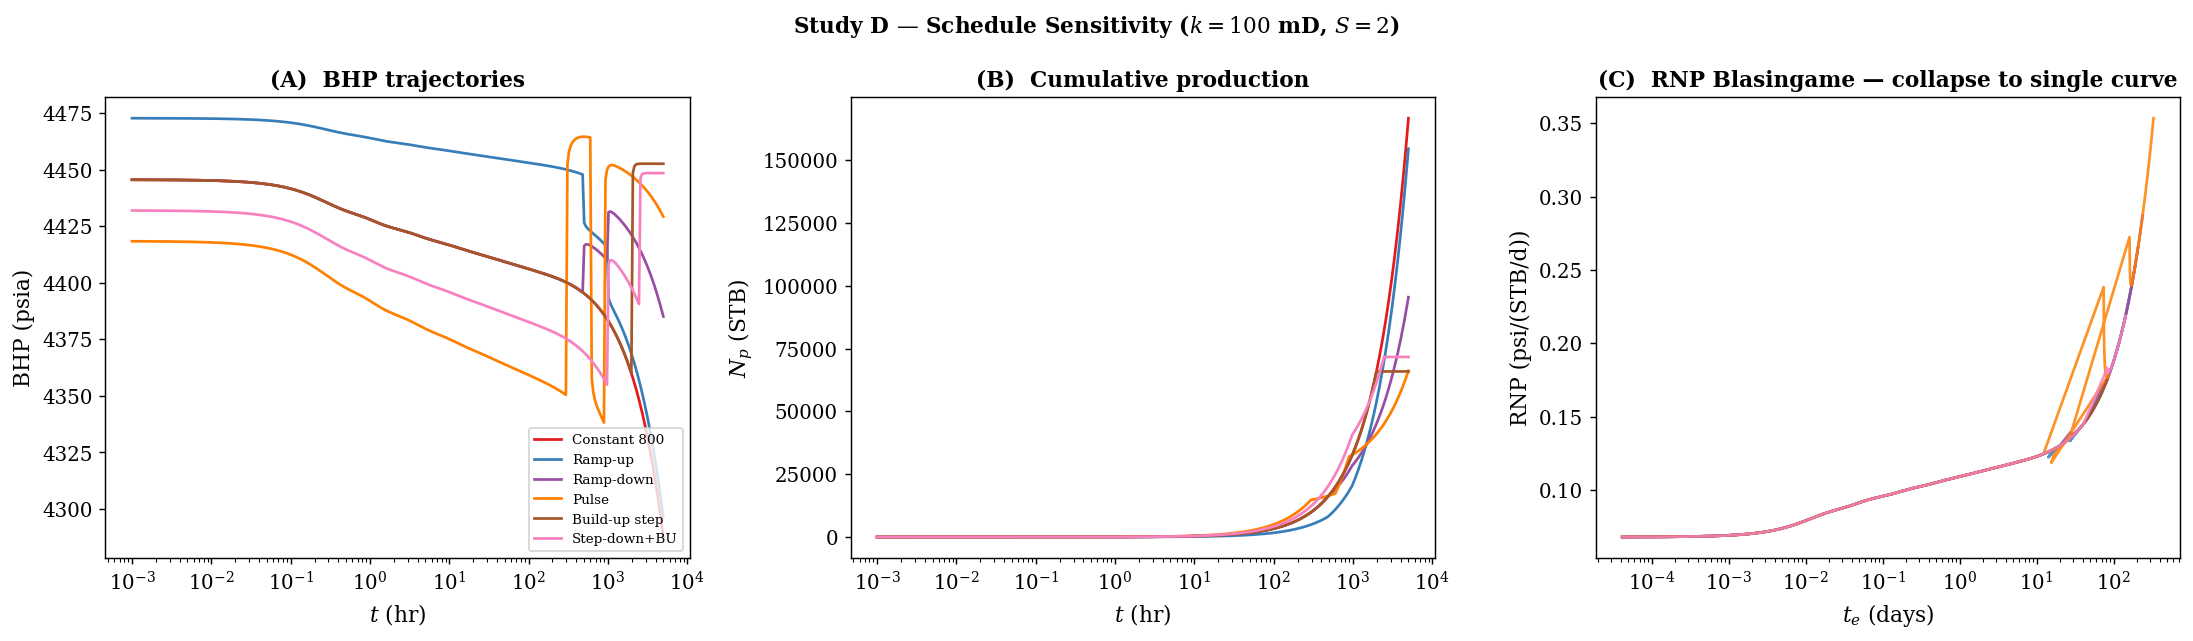

In [70]:
# ── Study D: Schedule sensitivity at fixed (k, S) ───────────────────────
# How does the choice of production schedule affect cumulative production
# and BDF onset?
k_D, s_D = 100, 2
schedules_D = {
    "Constant 800"   : [(0, 800)],
    "Ramp-up"        : [(0, 400), (500, 600), (1000, 800)],
    "Ramp-down"      : [(0, 800), (500, 600), (1000, 400)],
    "Pulse"          : [(0, 1200), (300, 200), (600, 1200), (900, 200)],
    "Build-up step"  : [(0, 800), (2000, 0)],
    "Step-down+BU"   : [(0, 1000), (1000, 500), (2500, 0)],
}
cmap_D = plt.cm.Set1

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
final_Np  = {}
for j, (nm, sch) in enumerate(schedules_D.items()):
    r   = predict(k_D, s_D, sch)
    col = cmap_D(j/len(schedules_D))
    axes[0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=1.5, label=nm)

    te, Np = material_balance_time(r["t_hr"], r["q_vec"])
    axes[1].semilogx(r["t_hr"], Np, color=col, lw=1.5)
    final_Np[nm] = Np[-1]

    rnp = rate_normalized_pressure(r["dp_psi"], r["q_vec"])
    axes[2].semilogx(te, rnp, color=col, lw=1.5, alpha=0.85)

axes[0].set_xlabel("$t$ (hr)"); axes[0].set_ylabel("BHP (psia)")
axes[0].set_title("(A)  BHP trajectories")
axes[0].legend(fontsize=7.5, loc="lower right")

axes[1].set_xlabel("$t$ (hr)"); axes[1].set_ylabel("$N_p$ (STB)")
axes[1].set_title("(B)  Cumulative production")

axes[2].set_xlabel("$t_e$ (days)"); axes[2].set_ylabel("RNP (psi/(STB/d))")
axes[2].set_title("(C)  RNP Blasingame — collapse to single curve")

print("Final cumulative production [STB]:")
for nm, v in sorted(final_Np.items(), key=lambda x: -x[1]):
    print(f"  {nm:<25} {v:>10.0f}")

fig.suptitle(f"Study D — Schedule Sensitivity ($k={k_D}$ mD, $S={s_D}$)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig14_studyD_schedule_sensitivity.pdf", bbox_inches="tight")
plt.show()


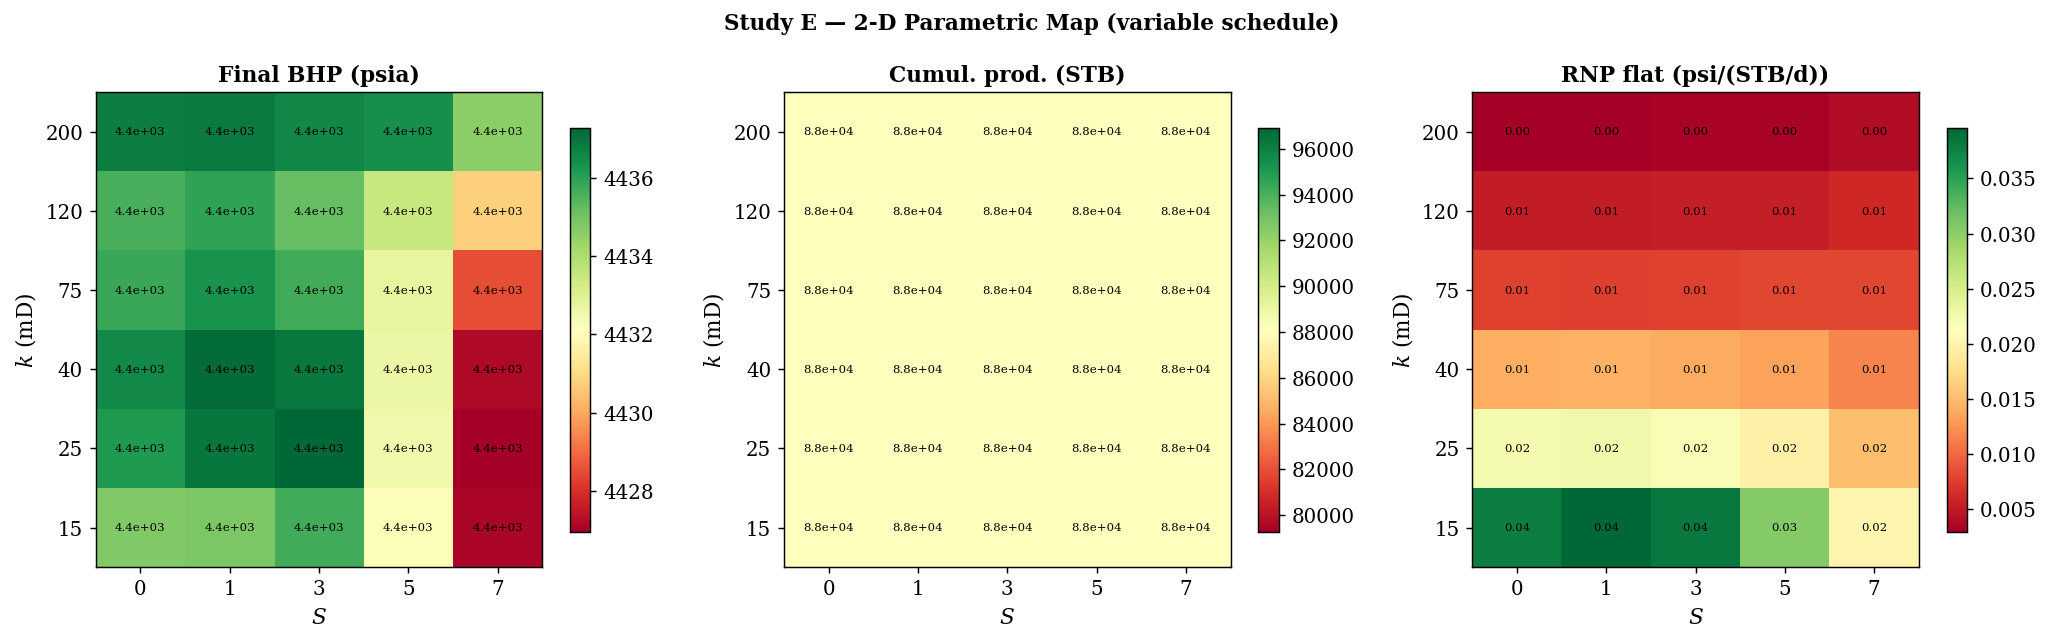

Study E complete — 30 ROM queries.


In [55]:
# ── Study E: 2-D parametric map with variable rate ──────────────────────
# For a fixed multi-segment schedule, sweep (k, S) and extract diagnostics
sched_E  = [(0, 800), (1500, 400), (4000, 0)]
k_fine_E = [15, 25, 40, 75, 120, 200]
s_fine_E = [0, 1, 3, 5, 7]

p_inf_map   = np.full((len(k_fine_E), len(s_fine_E)), np.nan)  # final BHP
np_map      = np.full((len(k_fine_E), len(s_fine_E)), np.nan)  # cumul prod
flat_rnp_map= np.full((len(k_fine_E), len(s_fine_E)), np.nan)  # RNP flat

for ik, k_v in enumerate(k_fine_E):
    for is_, s_v in enumerate(s_fine_E):
        r   = predict(k_v, s_v, sched_E)
        te, Np = material_balance_time(r["t_hr"], r["q_vec"])
        rnp_v  = rate_normalized_pressure(r["dp_psi"], r["q_vec"])
        tv, rv, dv = rnp_derivative(te, rnp_v)
        _, t_wbs_e, t_pss_e, *_ = physics_screen(k_v, s_v)
        mtr_e = (tv >= t_wbs_e/24) & (tv <= t_pss_e/24)
        flat_rnp_map[ik,is_]= np.median(dv[mtr_e]) if mtr_e.sum()>2 else np.nan
        p_inf_map[ik,is_]   = r["bhp_psia"][-1]
        np_map[ik,is_]      = Np[-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title in [
    (axes[0], p_inf_map,    "Final BHP (psia)"),
    (axes[1], np_map,       "Cumul. prod. (STB)"),
    (axes[2], flat_rnp_map, "RNP flat (psi/(STB/d))")]:
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn",
                   origin="lower")
    ax.set_xticks(range(len(s_fine_E))); ax.set_xticklabels(s_fine_E)
    ax.set_yticks(range(len(k_fine_E))); ax.set_yticklabels(k_fine_E)
    ax.set_xlabel("$S$"); ax.set_ylabel("$k$ (mD)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for i in range(len(k_fine_E)):
        for j in range(len(s_fine_E)):
            v = data[i,j]
            if np.isfinite(v):
                ax.text(j,i,f"{v:.1e}" if abs(v)>999 else f"{v:.2f}",
                        ha="center",va="center",fontsize=6.5,color="k")

fig.suptitle("Study E — 2-D Parametric Map (variable schedule)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig15_studyE_parametric_map.pdf", bbox_inches="tight")
plt.show()
print(f"Study E complete — {len(k_fine_E)*len(s_fine_E)} ROM queries.")


## 11. Summary and Performance Report

In [56]:
t0 = time.perf_counter()
for _ in range(20):
    query_rom(75, 2, T_PRED, schedule_qvec([(0,800),(500,400),(1500,0)], T_PRED))
rom_ms = (time.perf_counter()-t0)/20*1000

print("=" * 70)
print(" VARIABLE-RATE ROM — ARCHITECTURE & PERFORMANCE SUMMARY")
print("=" * 70)
print(f"  FOM                  : MRST {NX}×{NY} = {N_CELLS} cells")
print(f"  Training pairs       : {len(VALID_PAIRS)}/{len(K_GRID)*len(S_GRID)} (after physics screen)")
print(f"  Schedules used       : {len(SCHEDS)}  ({SCHEDS[0]}–{SCHEDS[-1]})")
print(f"    — single-rate      : {SINGLE_SCHEDS}")
print(f"    — variable-rate    : {VARIABLE_SCHEDS}")
print(f"  POD modes (n)        : {N_MODES}")
print(f"  Integrator           : Backward Euler (implicit, unconditionally stable)")
print(f"  RBF kernel           : linear, feature-normalised")
print(f"  Parametric range     : k ∈ [10,300] mD,  S ∈ [0,8]")
print(f"  Rate schedules       : arbitrary piecewise-constant q(t)")
print("-" * 70)
print(f"  Duhamel superposn    : exact for LTI ROM (linearity check ✓)")
print(f"  RTA module           : t_e, RNP, RNP' (Blasingame collapse ✓)")
print(f"  Horner build-up      : skin estimate from virtual well test ✓")
print(f"  Deconvolution        : Tikhonov regularised (lam auto-GCV) ✓")
print("-" * 70)
try:
    mean_out_err = df_val["out_err"].mean()
    mean_var_err = df_val[df_val["is_variable"]]["out_err"].mean()
    print(f"  Validation output err (all)    : {mean_out_err:.3e}")
    print(f"  Validation output err (var-q)  : {mean_var_err:.3e}")
except Exception:
    pass
print("-" * 70)
print(f"  ROM wall time/query  : {rom_ms:.2f} ms  (variable multi-segment schedule)")
print(f"  MRST wall time       : ~180,000 ms  (~3 min)")
speedup = 180000 / rom_ms
print(f"  Speed-up             : ~{speedup:,.0f}×")
print("=" * 70)
print(f"\nFigures → {FIG_DIR.resolve()}")
print(f"ROM     → {ROM_DIR.resolve()}")


 VARIABLE-RATE ROM — ARCHITECTURE & PERFORMANCE SUMMARY
  FOM                  : MRST 50×50 = 2500 cells
  Training pairs       : 36/36 (after physics screen)
  Schedules used       : 7  (1–7)
    — single-rate      : [1, 2, 3]
    — variable-rate    : [4, 5, 6, 7]
  POD modes (n)        : 15
  Integrator           : Backward Euler (implicit, unconditionally stable)
  RBF kernel           : linear, feature-normalised
  Parametric range     : k ∈ [10,300] mD,  S ∈ [0,8]
  Rate schedules       : arbitrary piecewise-constant q(t)
----------------------------------------------------------------------
  Duhamel superposn    : exact for LTI ROM (linearity check ✓)
  RTA module           : t_e, RNP, RNP' (Blasingame collapse ✓)
  Horner build-up      : skin estimate from virtual well test ✓
  Deconvolution        : Tikhonov regularised (lam auto-GCV) ✓
----------------------------------------------------------------------
  Validation output err (all)    : 7.908e-02
  Validation output err (v